# TVP5 · Project & Portfolio Impact Assessment
## Transition Valuation Project — Backtesting Cohort 2025

**Scope:** 9 infrastructure projects (3 Hospitals · 3 Hydro Power Plants · 3 Rail)
**Framework:** ESRS-aligned impact valuation across all six TVP value factor systems,
supply-chain tier expansion (T0–T10), IPCC AR6 scenario conditioning and ENCORE
dependency profiles.

| Part | Section |
|------|---------|
| **0** | Setup & data loading |
| **1A** | Supply-chain tiers T0 → T1 → T2 → T3-10 per project |
| **1B** | All six value factor systems (WifOR · UBA · CE Delft · UK · EPS · eQALY) |
| **1C** | IPCC AR6 scenarios (SSP1-1.9 → SSP5-8.5) |
| **1D** | Dependency profiles (ENCORE · WWF · InVEST) |
| **2** | Portfolio aggregation & stress-test |


## Data Alignment Disclaimer

> **This assessment is exploratory and is intended to provide an order-of-magnitude feel
> for the data. It is NOT designed for precise cross-project comparison.
> Currency units and time periods are NOT harmonised across projects.**

### Currency Alignment Issues

| Project | Indicator | Reported Value | Alignment Issue |
|---------|-----------|----------------|-----------------|
| HOSP-2 | S7.P8B.3 (Annual H&S expenditure) | 250,000,000 | Currency unspecified in source — assumed USD, but local currency (NGN) not excluded |
| RAIL-1/2/3 (Germany) | CAPEX | 1,190 / 1,350 / 2,460 MUSD | European projects; original figures likely EUR — no explicit EUR/USD conversion applied |
| HYDRO-3 / HOSP-3 (Germany) | CAPEX | 47 / 150 MUSD | Same EUR exposure |
| Value factors (UBA, CE Delft) | All | EUR_2025 / EUR_2021 | Converted to USD at indicative rates (1.10 / 1.18) |
| Value factors (UK Wellbeing) | All | GBP_2019 | Converted to USD at indicative rate (1.28) |

### Time Period Alignment Issues

| Project | Indicator | Reported Value | Alignment Issue |
|---------|-----------|----------------|-----------------|
| HOSP-1 | S7.X4B (Health beneficiaries) | 5,000,000 | Over 22-year operational life — not annualised |
| HOSP-2 | S7.X4B | 3,000 | Over 20-year horizon (~150-200 children/year) |
| HOSP-3 | S7.X4B | 500,000 | Described as 1.8M patients/year — appears single-year |
| HYDRO-1/2 | E2.Q8W.A | N/A | Plants not yet operational — first-year estimate used |
| HYDRO-3 | E2.Q8W.B | N/A | Operational — prior-year actual used |

**All data is self-reported by project promoters. Monetisation is illustrative — it conveys
relative scale and TVP5 framework applicability, not audited impact accounts.**


## Part 0 · Setup and Data Loading

In [1]:
import warnings, sys
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mtick
import matplotlib.patches as mpatches
import matplotlib.cm      as cm
import matplotlib.colors  as mcolors

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.3f}".format)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (13, 5),
                     "axes.spines.top": False, "axes.spines.right": False})

# ── paths ─────────────────────────────────────────────────────────────────────
ROOT   = Path("../../..").resolve()   # /home/deuler
TVP4   = ROOT / "tvp4"
TVP5   = ROOT / "tvp5"
S4BT   = ROOT / "s4_backtesting"
S4DEP  = ROOT / "s4_dependency"
S4SCE  = ROOT / "s4_scenarios"
PA_DIR = Path(".").resolve()

# ── value factor source directories ──────────────────────────────────────────
VF_WIFOR   = TVP5 / "value-factors" / "output"
VF_UBA     = TVP4 / "uba-value-factors" / "output"
VF_CEDELFT = TVP4 / "cedelft-value-factors" / "output"
VF_UK      = TVP4 / "uk-value-factors" / "output"
VF_EPS     = TVP4 / "stockholm-value-factors" / "output"
VF_EQALY   = TVP4 / "valuingimpact-value-factors" / "output"

print("ROOT :", ROOT)
print("VF paths:")
for name, p in [("WifOR",VF_WIFOR),("UBA",VF_UBA),("CE Delft",VF_CEDELFT),
                ("UK",VF_UK),("EPS",VF_EPS),("eQALY",VF_EQALY)]:
    print(f"  {name:<10}: {p}  exists={p.exists()}")

# ── ID cross-walk ─────────────────────────────────────────────────────────────
XWALK = {
    "HOSP-1":  "Proj_001",  "HOSP-2":  "Proj_002",  "HOSP-3":  "Proj_003",
    "HYDRO-1": "Hydro_AF",  "HYDRO-2": "Hydro_AS",  "HYDRO-3": "Hydro_EU",
    "RAIL-1":  "Rail_EU_DEV","RAIL-2": "Rail_EU_OP1","RAIL-3": "Rail_EU_OP2",
}
XWALK_INV = {v: k for k, v in XWALK.items()}

# ── currency conversion rates (indicative, 2025) ─────────────────────────────
EUR2025_TO_USD = 1.10   # EUR_2025 → USD
EUR2021_TO_USD = 1.18   # EUR_2021 → USD
GBP2019_TO_USD = 1.28   # GBP_2019 → USD


ROOT : /home/deuler
VF paths:
  WifOR     : /home/deuler/tvp5/value-factors/output  exists=True
  UBA       : /home/deuler/tvp4/uba-value-factors/output  exists=True
  CE Delft  : /home/deuler/tvp4/cedelft-value-factors/output  exists=True
  UK        : /home/deuler/tvp4/uk-value-factors/output  exists=True
  EPS       : /home/deuler/tvp4/stockholm-value-factors/output  exists=True
  eQALY     : /home/deuler/tvp4/valuingimpact-value-factors/output  exists=True


In [2]:
# ── project assessment inputs ─────────────────────────────────────────────────
master   = pd.read_csv(PA_DIR / "01_project_master.csv")
indics   = pd.read_csv(PA_DIR / "02_impact_indicators.csv")
monin    = pd.read_csv(PA_DIR / "03_monetisation_inputs.csv")

# ── s4_dependency outputs ────────────────────────────────────────────────────
wwf      = pd.read_csv(S4DEP / "assessment_output" / "wwf_risk_scores.csv")
stress   = pd.read_csv(S4DEP / "assessment_output" / "portfolio_stress_test.csv")
dep_heat = pd.read_csv(S4DEP / "assessment_output" / "dependency_heatmap.csv")

wwf["project_id"]    = wwf["project_id"].map(XWALK_INV).fillna(wwf["project_id"])
stress["project_id"] = stress["project_id"].map(XWALK_INV).fillna(stress["project_id"])

ENCORE_FILES = {
    "HOSP-1": "encore_materiality_Proj_001.csv",  "HOSP-2": "encore_materiality_Proj_002.csv",
    "HOSP-3": "encore_materiality_Proj_003.csv",  "HYDRO-1": "encore_materiality_Hydro_AF.csv",
    "HYDRO-2": "encore_materiality_Hydro_AS.csv", "HYDRO-3": "encore_materiality_Hydro_EU.csv",
    "RAIL-1":  "encore_materiality_Rail_EU_DEV.csv",
    "RAIL-2":  "encore_materiality_Rail_EU_OP1.csv",
    "RAIL-3":  "encore_materiality_Rail_EU_OP2.csv",
}
encore = {pid: pd.read_csv(S4DEP/"assessment_output"/fn) for pid, fn in ENCORE_FILES.items()}

# ── s4_scenarios outputs ──────────────────────────────────────────────────────
ipcc_w  = pd.read_csv(S4SCE / "results" / "ipcc_nexus_weights.csv")
scc_dmg = pd.read_csv(S4SCE / "results_scc_damage.csv")
tvp_int = pd.read_csv(S4SCE / "osemosys" / "results" / "tvpdbio_intensity_factors.csv")

print("master rows:", len(master), " | indicators rows:", len(indics))
print("SSPs:", sorted(ipcc_w.ssp.unique()))
master


master rows: 9  | indicators rows: 43
SSPs: ['SSP1-1.9', 'SSP2-4.5', 'SSP3-7.0', 'SSP4-6.0', 'SSP5-8.5']


,project_id,sector,region,country,stage,capex_musd,bond_yield,annual_coupon_musd,total_10y_return_musd,data_year,source_file
0,HOSP-1,Hospitals,LATAM,Brazil,Development,147,0.081,11.848,265.482,2025,20260317_Data_Greenings_clean_NG.xlsx
1,HOSP-2,Hospitals,Africa,Nigeria,Development,250,0.116,28.900,539.000,2025,20260317_Data_Greenings_clean_NG.xlsx
2,HOSP-3,Hospitals,Europe,Germany,Operational,150,0.051,7.590,225.900,2025,20260317_Data_Greenings_clean_NG.xlsx
3,HYDRO-1,Hydro Power Plant,Africa,Nigeria,Construction,200,0.110,22.000,420.000,2025,20260317_Data_Greenings_clean_NG.xlsx
4,HYDRO-2,Hydro Power Plant,Asia,Malaysia,Development,400,0.057,22.800,628.000,2025,20260317_Data_Greenings_clean_NG.xlsx
5,HYDRO-3,Hydro Power Plant,Europe,Germany,Operation,47,0.045,2.115,68.150,2025,20260317_Data_Greenings_clean_NG.xlsx
6,RAIL-1,Rail,Europe,Germany,Development,1190,0.048,57.596,"1,765.960",2025,20260317_Data_Greenings_clean_NG.xlsx
7,RAIL-2,Rail,Europe,Germany,Operation,1350,0.048,65.340,"2,003.400",2025,20260317_Data_Greenings_clean_NG.xlsx
8,RAIL-3,Rail,Europe,Germany,Operation,2460,0.048,119.064,"3,650.640",2025,20260317_Data_Greenings_clean_NG.xlsx


### 0.1 Reference tables

In [3]:
SECTOR_NACE = {
    "Hospitals":         {"nace": "Q",    "nace_full": "Q86",  "label": "Human health activities"},
    "Hydro Power Plant": {"nace": "D35",  "nace_full": "D3511","label": "Electricity generation (hydro)"},
    "Rail":              {"nace": "H49",  "nace_full": "H4910","label": "Passenger rail transport"},
}
COUNTRY_ISO = {"Brazil":"BRA","Nigeria":"NGA","Germany":"DEU","Malaysia":"MYS"}
COUNTRY_REGION = {"BRA":"LATAM","NGA":"Africa","DEU":"Europe","MYS":"Asia"}
SSP_COLOURS = {
    "SSP1-1.9":"#2ecc71","SSP2-4.5":"#3498db",
    "SSP3-7.0":"#e67e22","SSP4-6.0":"#9b59b6","SSP5-8.5":"#e74c3c",
}
SSP_ORDER = ["SSP1-1.9","SSP2-4.5","SSP4-6.0","SSP3-7.0","SSP5-8.5"]
PROJ_REGION_MAP = {"LATAM":"LATAM","Africa":"Africa","Asia":"Asia","Europe":"Europe"}

scc_2025 = (
    scc_dmg[scc_dmg.year==2025]
    .groupby(["scenario","region"])["scc_usd_per_tco2"].first().reset_index()
)
print("SCC 2025 sample (SSP2-4.5):")
print(scc_2025[scc_2025.scenario=="SSP2-4.5"].to_string(index=False))


SCC 2025 sample (SSP2-4.5):
scenario region  scc_usd_per_tco2
SSP2-4.5 Africa           215.000
SSP2-4.5   Asia           215.000
SSP2-4.5 Europe           215.000
SSP2-4.5  LATAM           215.000


### 0.2 Sector Allocation — Construction vs. Operational NACE

**Design decision:** All projects are assessed under their **operational sector** NACE code
(Hospitals → Q86, Hydro → D3511, Rail → H4910) regardless of project stage.

**Rationale:**
1. **Cashflow basis.** The bond cashflow generated after construction comes from the
   operational activity — a hospital repays its bond from health services revenue, not
   from construction revenues. The impact assessment must reflect this.
2. **Positive contribution claims.** All claimed positive contributions (GHG avoided,
   health beneficiaries, resilience beneficiaries) describe *operational* impacts.
   A hydro plant under construction already knows its first-year GHG avoidance figure
   (E2.Q8W.B) — this is an electricity-sector metric, not a construction metric.
3. **Value factor calibration.** WifOR OHS coefficients (VSL, disease rates) are
   calibrated by country × operational NACE sector. Using "Construction (F)" for
   HYDRO-1 would apply construction-site OHS costs, not the power-sector context
   the project investor is assessing.
4. **Supply-chain capture.** Construction-phase Scope-3 exposure is explicitly modelled
   at **Tier 1 — Civil Engineering (F)** within the supply-chain tier analysis (Section 1A).
   This correctly separates the construction *input* from the operational *output*.

The table below shows the confirmed allocation for all 9 projects.


In [4]:
# ── Confirm sector → NACE allocation ─────────────────────────────────────────
STAGE_NACE_NOTE = {
    "Development":  "pre-construction — use operational NACE (future cashflow sector)",
    "Construction": "under construction — ← use operational NACE; Tier-1 Civil Eng. captures build exposure",
    "Operational":  "operating — operational NACE confirmed",
    "Operation":    "operating — operational NACE confirmed",
}

print(f"{'Project':<10} {'Stage':<15} {'NACE':<8} {'Sector label':<32} Note")
print("-" * 100)
for _, row in master.iterrows():
    pid   = row.project_id
    iso   = COUNTRY_ISO.get(row.country, "???")
    nace  = SECTOR_NACE[row.sector]["nace_full"]
    label = SECTOR_NACE[row.sector]["label"]
    note  = STAGE_NACE_NOTE.get(row.stage, "")
    marker = "  ⚙️ CONSTRUCTION" if row.stage == "Construction" else ""
    print(f"{pid:<10} {row.stage:<15} {nace:<8} {label:<32} {note}{marker}")

print()
print("✓ All projects use OPERATIONAL sector NACE — consistent with cashflow and positive-contribution basis.")
print("  Construction-phase supply-chain exposure is captured at Tier 1 (Civil Engineering F) in Section 1A.")


Project    Stage           NACE     Sector label                     Note
----------------------------------------------------------------------------------------------------
HOSP-1     Development     Q86      Human health activities          pre-construction — use operational NACE (future cashflow sector)
HOSP-2     Development     Q86      Human health activities          pre-construction — use operational NACE (future cashflow sector)
HOSP-3     Operational     Q86      Human health activities          operating — operational NACE confirmed
HYDRO-1    Construction    D3511    Electricity generation (hydro)   under construction — ← use operational NACE; Tier-1 Civil Eng. captures build exposure  ⚙️ CONSTRUCTION
HYDRO-2    Development     D3511    Electricity generation (hydro)   pre-construction — use operational NACE (future cashflow sector)
HYDRO-3    Operation       D3511    Electricity generation (hydro)   operating — operational NACE confirmed
RAIL-1     Development     H4910  

---
## Part 1 · Per-Project Deep-Dive

In [5]:
TIER_MULTS = {
    "Hospitals": [
        (0, "Own operations",              1.00, 1.00, 1.00, 1.00),
        (1, "Construction & Civil works",  0.82, 0.71, 0.54, 0.43),
        (1, "Medical Equipment (C26-C28)", 0.28, 0.41, 0.12, 0.08),
        (1, "Pharma & Chemicals (C20-C21)",0.19, 0.22, 0.09, 0.14),
        (2, "Steel & Metal Products",      0.61, 0.38, 0.31, 0.52),
        (2, "Cement & Concrete (C23)",     0.74, 0.29, 0.68, 0.39),
        (2, "Electronics Manufacture",     0.17, 0.52, 0.07, 0.06),
        (2, "Wholesale trade (G46)",       0.06, 0.27, 0.03, 0.05),
        (3, "Iron ore & Mining (B)",       0.91, 0.18, 0.83, 0.77),
        (3, "Fossil fuels (B+C19)",        1.12, 0.14, 0.42, 0.31),
        (3, "Plastics & Rubber (C22)",     0.23, 0.31, 0.15, 0.12),
        (4, "Agriculture (A01)",           0.04, 0.44, 0.89, 1.34),
        (5, "Global commodity trade",      0.11, 0.22, 0.19, 0.16),
    ],
    "Hydro Power Plant": [
        (0, "Own operations",              1.00, 1.00, 1.00, 1.00),
        (1, "Civil Engineering (F)",       0.79, 0.68, 0.51, 0.37),
        (1, "Turbines & Machinery (C28)",  0.42, 0.44, 0.18, 0.11),
        (1, "Electrical Equipment (C27)",  0.31, 0.47, 0.14, 0.09),
        (2, "Steel & Metal Casting (C24)", 0.68, 0.34, 0.29, 0.55),
        (2, "Cement & Concrete (C23)",     0.74, 0.29, 0.68, 0.39),
        (2, "Copper & Non-ferrous (C24)",  0.59, 0.28, 0.22, 0.41),
        (3, "Iron & Steel Smelting",       0.88, 0.17, 0.77, 0.69),
        (3, "Bauxite / Aluminium ore",     0.96, 0.21, 0.91, 0.83),
        (4, "Mining & Quarrying (B)",      0.87, 0.19, 0.81, 0.74),
        (5, "Logistics & Shipping (H50)",  0.14, 0.31, 0.07, 0.22),
        (6, "Fuel for construction equip.",0.93, 0.12, 0.38, 0.28),
        (7, "Global commodity trade",      0.11, 0.22, 0.19, 0.16),
    ],
    "Rail": [
        (0, "Own operations",              1.00, 1.00, 1.00, 1.00),
        (1, "Civil Engineering (F)",       0.79, 0.68, 0.51, 0.37),
        (1, "Steel Rail & Track (C24)",    0.71, 0.31, 0.34, 0.58),
        (1, "Rolling Stock (C30)",         0.38, 0.51, 0.16, 0.10),
        (1, "Signalling & Electronics",    0.24, 0.53, 0.10, 0.07),
        (2, "Steel production (C24)",      0.68, 0.34, 0.29, 0.55),
        (2, "Cement & Concrete (C23)",     0.74, 0.29, 0.68, 0.39),
        (2, "Aluminium extrusions (C24)",  0.54, 0.26, 0.20, 0.38),
        (3, "Coal for steel (B)",          1.02, 0.15, 0.44, 0.33),
        (3, "Iron ore (B)",                0.88, 0.17, 0.77, 0.69),
        (4, "Mining & Extraction (B)",     0.87, 0.19, 0.81, 0.74),
        (5, "Maritime shipping (H50)",     0.14, 0.31, 0.07, 0.22),
        (6, "Fuel & lubricants (C19)",     0.93, 0.12, 0.38, 0.28),
        (7, "Rubber & Plastics (C22)",     0.23, 0.31, 0.15, 0.12),
        (8, "Glass & Mineral wool (C23)",  0.52, 0.27, 0.45, 0.21),
        (9, "Chemicals (C20)",             0.31, 0.35, 0.18, 0.19),
        (10,"Global commodity trade",      0.11, 0.22, 0.19, 0.16),
    ],
}
TIER_COLS = ["tier","supply_chain_stage","ghg_mult","labour_mult","land_mult","water_mult"]
TIER_DFS  = {s: pd.DataFrame(v, columns=TIER_COLS) for s, v in TIER_MULTS.items()}
print("Tier tables ready:", list(TIER_DFS))


Tier tables ready: ['Hospitals', 'Hydro Power Plant', 'Rail']


### Positive Impact at a Glance — All Projects

*Claimed positive contributions (PC) as reported by project promoters before detailed assessment.*

In [6]:
POSITIVE_IMPACTS = {
    "HOSP-1": {
        "sector":"Hospitals","region":"LATAM / Brazil","stage":"Development","capex":"147 MUSD",
        "headline":"5 million people gain access to health infrastructure over project lifetime.",
        "pcs":[
            ("Health & Safety (S1-89)",       "Improved H&S for communities: YES"),
            ("H&S type",                       "Health Infrastructure + Medical Equipment"),
            ("Biodiversity / NbS (E4-AR34)",   "Nature-Based Solutions: YES"),
            ("H&S CAPEX share",                "2.72% of project CAPEX"),
            ("H&S beneficiaries",              "5,000,000 persons (22-yr operational life)"),
        ],
    },
    "HOSP-2": {
        "sector":"Hospitals","region":"Africa / Nigeria","stage":"Development","capex":"250 MUSD",
        "headline":"Dedicated children's facility — 100% CAPEX allocated to H&S measures.",
        "pcs":[
            ("Health & Safety (S1-89)",        "Improved H&S: YES"),
            ("H&S type",                        "Diagnostics, Consumables, Drugs & Medication"),
            ("Biodiversity / NbS",              "Nature-Based Solutions: NO"),
            ("H&S CAPEX share",                 "100% of project CAPEX"),
            ("Annual H&S expenditure",          "250,000,000 (currency unspecified)"),
            ("H&S beneficiaries",               "3,000 persons (20-yr; ~150-200 children/yr)"),
        ],
    },
    "HOSP-3": {
        "sector":"Hospitals","region":"Europe / Germany","stage":"Operational","capex":"150 MUSD",
        "headline":"Operational hospital, 1.8M patients/year; 100% H&S CAPEX allocation.",
        "pcs":[
            ("Health & Safety (S1-89)",        "Improved H&S: YES"),
            ("H&S type",                        "Health Infrastructure"),
            ("Biodiversity / NbS",              "Nature-Based Solutions: YES"),
            ("H&S CAPEX share",                 "100% of project CAPEX"),
            ("H&S beneficiaries",               "500,000 persons (1.8M patients/year)"),
        ],
    },
    "HYDRO-1": {
        "sector":"Hydro Power Plant","region":"Africa / Nigeria","stage":"Construction","capex":"200 MUSD",
        "headline":"150,000 tCO2e avoided in first operating year; community health co-benefit.",
        "pcs":[
            ("GHG avoided prior yr (E1-34a)",   "N/A (not yet operational)"),
            ("GHG avoided 1st yr (E1-34a)",     "150,000 tCO2e/yr"),
            ("Health beneficiaries",             "15,000 persons (new equipment; departmental hospital)"),
        ],
    },
    "HYDRO-2": {
        "sector":"Hydro Power Plant","region":"Asia / Malaysia","stage":"Development","capex":"400 MUSD",
        "headline":"834,000 tCO2e avoided annually — largest single-project GHG contribution.",
        "pcs":[
            ("GHG avoided prior yr (E1-34a)",   "N/A (not yet operational)"),
            ("GHG avoided 1st yr (E1-34a)",     "834,218.74 tCO2e/yr"),
            ("Health beneficiaries",             "Not a claimed PC"),
        ],
    },
    "HYDRO-3": {
        "sector":"Hydro Power Plant","region":"Europe / Germany","stage":"Operation","capex":"47 MUSD",
        "headline":"Operational small-hydro; 6,126 tCO2e verified prior-year avoided emissions.",
        "pcs":[
            ("GHG avoided prior yr (E1-34a)",   "6,126 tCO2e/yr"),
            ("GHG avoided 1st yr (E1-34a)",     "N/A (operational; prior-year figure used)"),
            ("Health beneficiaries",             "Not a claimed PC"),
        ],
    },
    "RAIL-1": {
        "sector":"Rail","region":"Europe / Germany","stage":"Development","capex":"1,190 MUSD",
        "headline":"5.5M resilience beneficiaries; combined GHG + air quality + adaptation PCs.",
        "pcs":[
            ("GHG avoided (E1-34a)",            "23,364 tCO2e/yr"),
            ("Air quality improvement (E2-28a)", "Improved Air Quality"),
            ("Air quality CAPEX share",          "<1% of CAPEX"),
            ("Air quality beneficiaries",        "150,000 persons"),
            ("Resilience domain (E1-69a)",       "Critical Infrastructure"),
            ("Resilience CAPEX share",           "<5% of CAPEX"),
            ("Resilience beneficiaries",         "5,500,000 persons (5.5M/year)"),
        ],
    },
    "RAIL-2": {
        "sector":"Rail","region":"Europe / Germany","stage":"Operation","capex":"1,350 MUSD",
        "headline":"Operational rail; 130,000 tCO2e avoided per year from modal shift.",
        "pcs":[
            ("GHG avoided (E1-34a)",            "130,000 tCO2e/yr"),
            ("Air quality / Resilience",         "Not claimed PCs"),
        ],
    },
    "RAIL-3": {
        "sector":"Rail","region":"Europe / Germany","stage":"Operation","capex":"2,460 MUSD",
        "headline":"Largest CAPEX project; 90,000 tCO2e avoided annually from operational rail.",
        "pcs":[
            ("GHG avoided (E1-34a)",            "90,000 tCO2e/yr"),
            ("Air quality / Resilience",         "Not claimed PCs"),
        ],
    },
}

print("=" * 88)
print(f"{'PROJECT POSITIVE IMPACT AT A GLANCE':^88}")
print("=" * 88)
print("  Warning: currency and time periods are NOT harmonised. Self-reported data only.")
print("=" * 88)
for pid, d in POSITIVE_IMPACTS.items():
    print(f"\n  {pid}  |  {d['sector']}  |  {d['region']}  |  Stage: {d['stage']}  |  CAPEX: {d['capex']}")
    print(f"  HEADLINE: {d['headline']}")
    for ind, val in d["pcs"]:
        print(f"    {ind:<45} {val}")
print(f"\n{'='*88}")


                          PROJECT POSITIVE IMPACT AT A GLANCE                           

  HOSP-1  |  Hospitals  |  LATAM / Brazil  |  Stage: Development  |  CAPEX: 147 MUSD
  HEADLINE: 5 million people gain access to health infrastructure over project lifetime.
    Health & Safety (S1-89)                       Improved H&S for communities: YES
    H&S type                                      Health Infrastructure + Medical Equipment
    Biodiversity / NbS (E4-AR34)                  Nature-Based Solutions: YES
    H&S CAPEX share                               2.72% of project CAPEX
    H&S beneficiaries                             5,000,000 persons (22-yr operational life)

  HOSP-2  |  Hospitals  |  Africa / Nigeria  |  Stage: Development  |  CAPEX: 250 MUSD
  HEADLINE: Dedicated children's facility — 100% CAPEX allocated to H&S measures.
    Health & Safety (S1-89)                       Improved H&S: YES
    H&S type                                      Diagnostics, Consumables, Dr

### 1A · Supply-Chain Tiers (T0 → T1 → T2 → T3-10)

*Leontief IO multiplier × direct CAPEX gives scope-3 exposure per impact driver.*

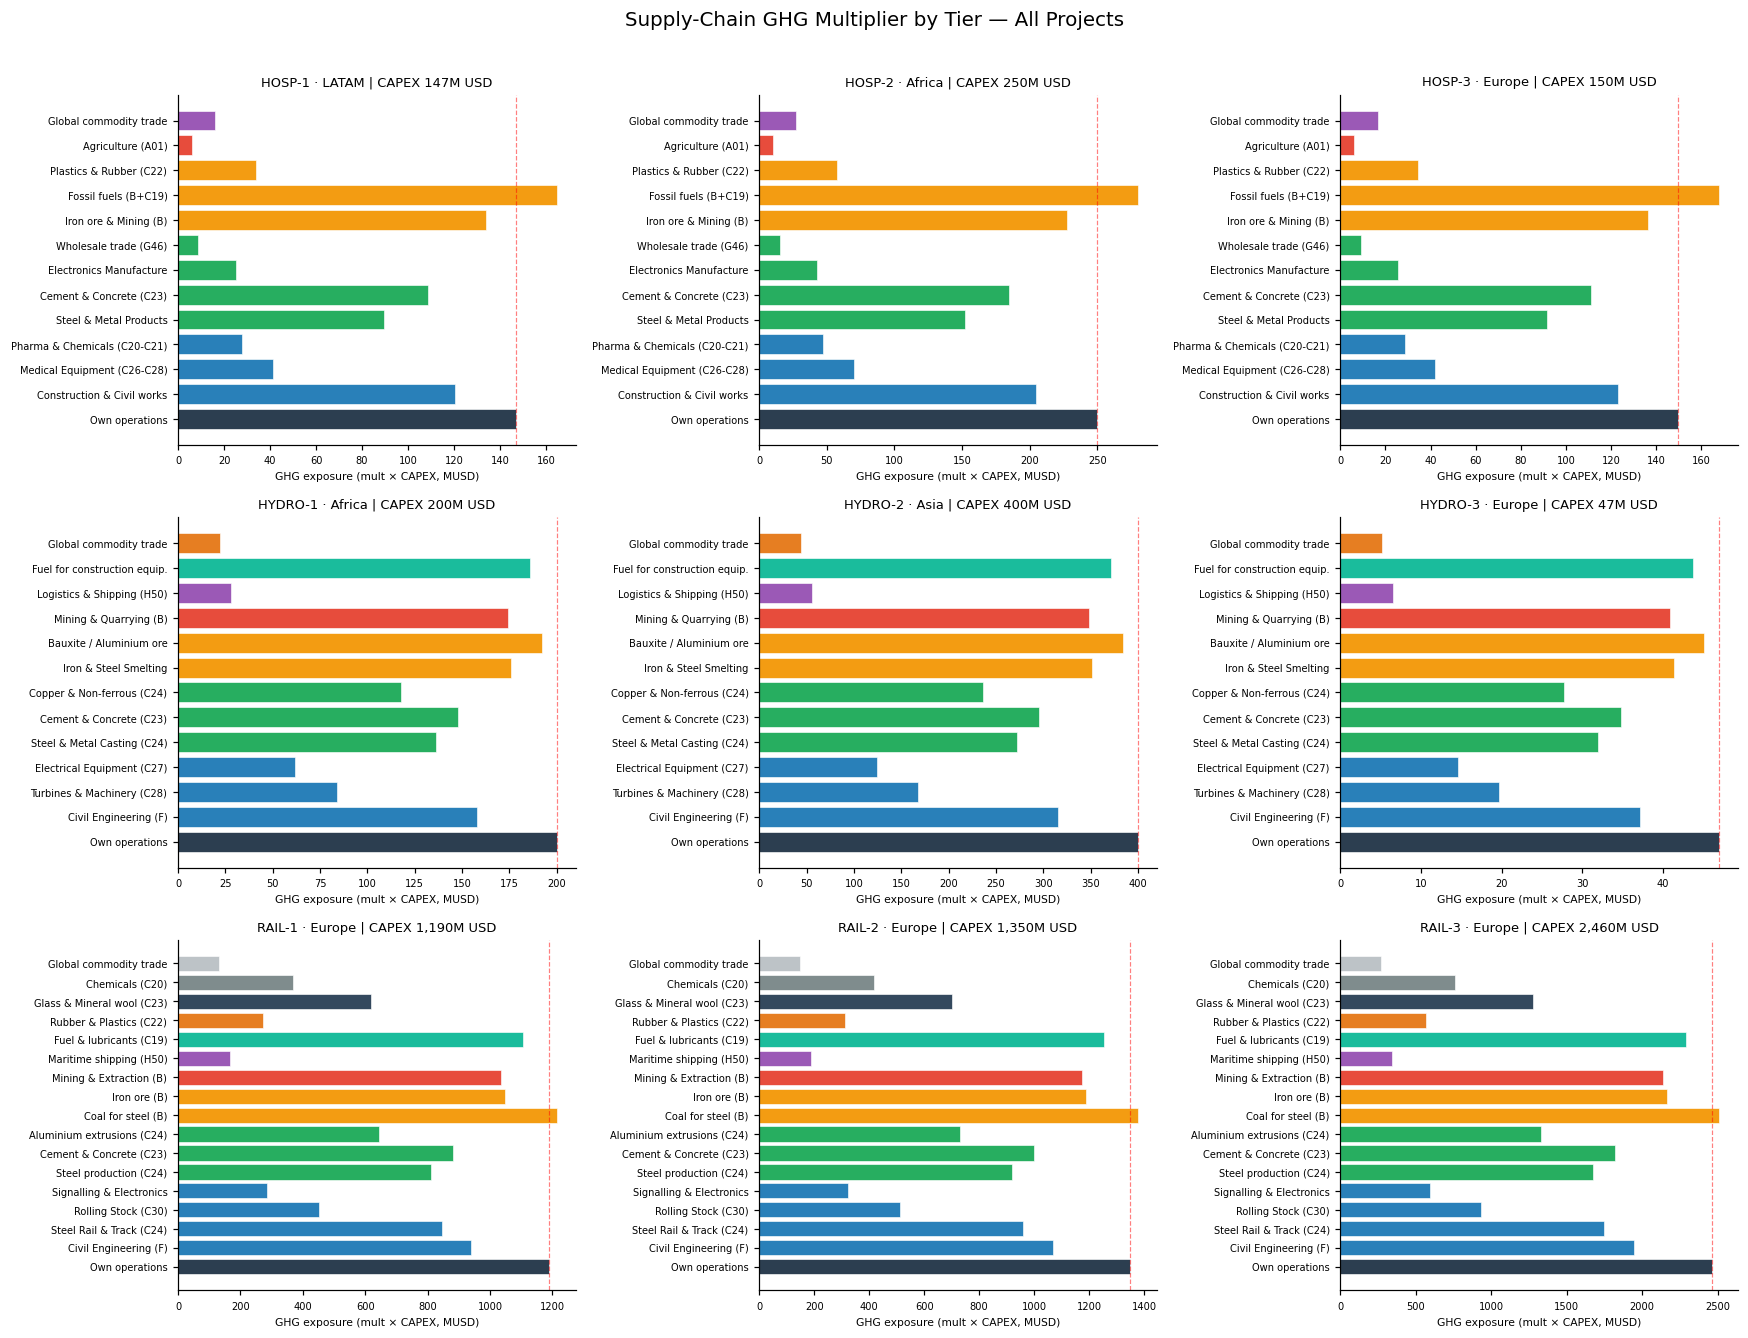

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharey=False)
fig.suptitle("Supply-Chain GHG Multiplier by Tier — All Projects", fontsize=13, y=1.01)

TIER_COLORS = {0:"#2c3e50",1:"#2980b9",2:"#27ae60",3:"#f39c12",
               4:"#e74c3c",5:"#9b59b6",6:"#1abc9c",7:"#e67e22",
               8:"#34495e",9:"#7f8c8d",10:"#bdc3c7"}

for ax, (_, row) in zip(axes.flat, master.iterrows()):
    pid   = row.project_id
    capex = row.capex_musd
    tdf   = TIER_DFS[row.sector].copy()
    tdf["ghg_abs"] = tdf.ghg_mult * capex
    colours = [TIER_COLORS.get(t, "#95a5a6") for t in tdf.tier]
    ax.barh(tdf.supply_chain_stage, tdf.ghg_abs, color=colours,
            edgecolor="white", linewidth=0.4)
    ax.set_title(f"{pid} · {row.region} | CAPEX {capex:,.0f}M USD", fontsize=8.5)
    ax.set_xlabel("GHG exposure (mult × CAPEX, MUSD)", fontsize=7)
    ax.tick_params(axis='y', labelsize=6.5); ax.tick_params(axis='x', labelsize=6.5)
    ax.axvline(capex, color="red", lw=0.8, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(PA_DIR / "fig_1a_supply_chain_ghg.png", bbox_inches="tight", dpi=130)
plt.show()


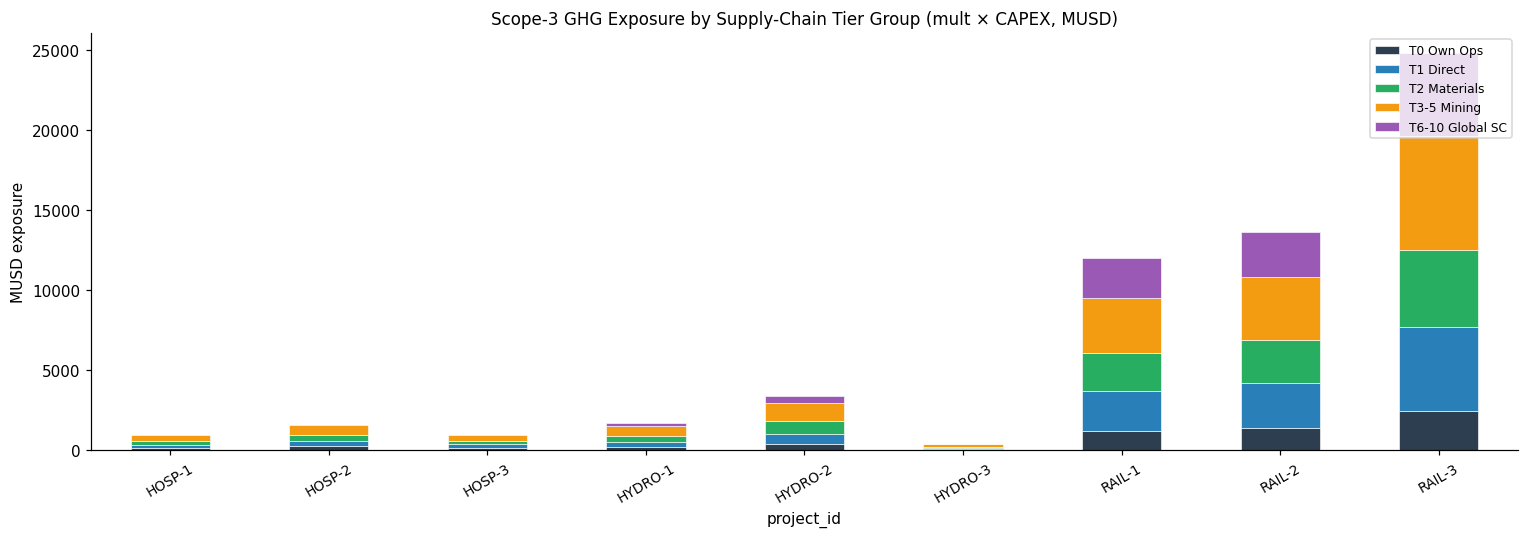

In [8]:
tier_groups = {
    "T0 Own Ops":      lambda t: t == 0,
    "T1 Direct":       lambda t: t == 1,
    "T2 Materials":    lambda t: t == 2,
    "T3-5 Mining":     lambda t: 3 <= t <= 5,
    "T6-10 Global SC": lambda t: t >= 6,
}
summary_rows = []
for _, row in master.iterrows():
    tdf = TIER_DFS[row.sector].copy()
    tdf["ghg_abs"]    = tdf.ghg_mult   * row.capex_musd
    tdf["labour_abs"] = tdf.labour_mult * row.capex_musd
    tdf["land_abs"]   = tdf.land_mult   * row.capex_musd
    tdf["water_abs"]  = tdf.water_mult  * row.capex_musd
    for grp, cond in tier_groups.items():
        sub = tdf[tdf.tier.apply(cond)]
        summary_rows.append({
            "project_id": row.project_id, "sector": row.sector,
            "region": row.region, "tier_group": grp,
            "ghg": sub.ghg_abs.sum(), "labour": sub.labour_abs.sum(),
            "land": sub.land_abs.sum(), "water": sub.water_abs.sum(),
        })
sc_summary = pd.DataFrame(summary_rows)

fig, ax = plt.subplots(figsize=(14, 5))
pivot = sc_summary.pivot_table(index="project_id", columns="tier_group",
                                values="ghg", aggfunc="sum")[list(tier_groups)]
pivot.plot(kind="bar", stacked=True, ax=ax,
           color=["#2c3e50","#2980b9","#27ae60","#f39c12","#9b59b6"],
           edgecolor="white", linewidth=0.4)
ax.set_title("Scope-3 GHG Exposure by Supply-Chain Tier Group (mult × CAPEX, MUSD)", fontsize=11)
ax.set_ylabel("MUSD exposure"); ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1a_tier_group_stacked.png", bbox_inches="tight", dpi=130)
plt.show()


---
### 1B · Value Factor Systems

Six independent value factor systems are applied to the same set of project indicators.
Each system reflects a different methodological philosophy:

| System | Institution | Unit | Primary Capital | Main Strength |
|--------|-------------|------|-----------------|---------------|
| **WifOR** | WifOR Institute | USD (2023) | Multiple | IO-calibrated, multi-capital |
| **UBA** | German Federal Env. Agency | EUR_2025 / t | Natural | Regulatory reference for DE/EU |
| **CE Delft** | CE Delft | EUR_2021 / kg | Natural | European environmental prices |
| **UK Wellbeing** | HM Treasury | GBP_2019 / WELLBY | Human | Wellbeing-adjusted life years |
| **EPS / Stockholm** | IVL (Stockholm) | ELU / kg | Natural | Multi-pollutant priority scores |
| **eQALY** | Valuing Impact / IHME | USD (2023) | Human | DALY-based, global coverage |

**Alignment warning:** Currency and time periods are not harmonised — all monetary
results are indicative only and intended to illustrate order-of-magnitude scale.


#### 1B-1 · WifOR Value Factors

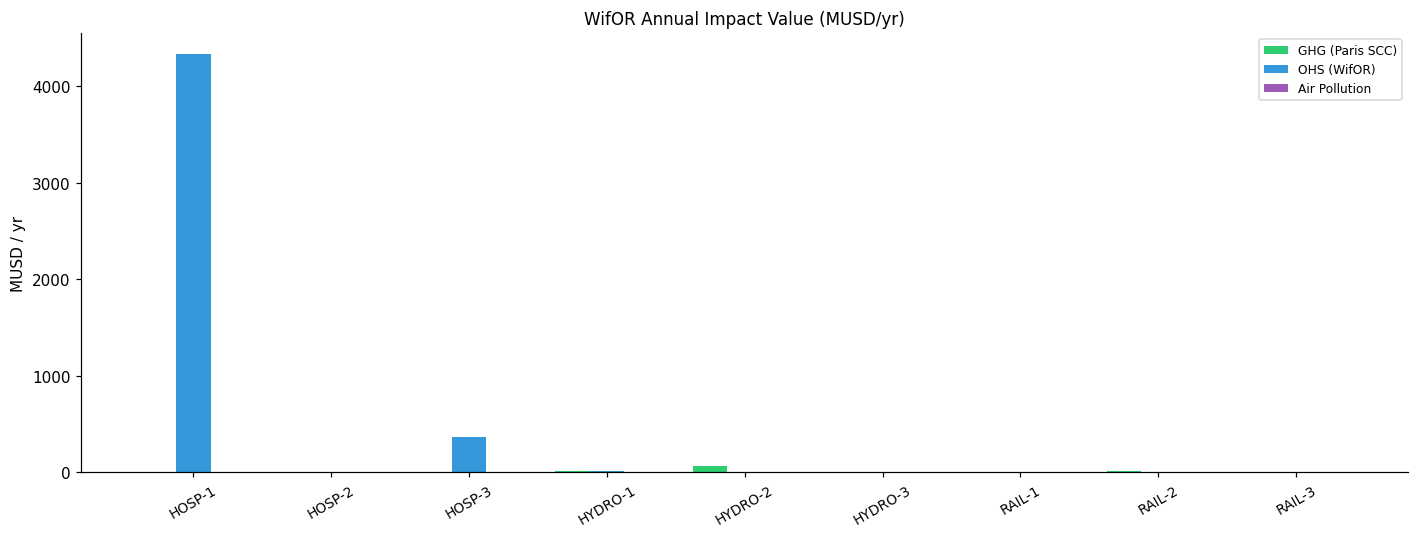

            ghg_musd_yr  ohs_musd_yr  ap_musd_yr  total_musd_yr
project_id                                                     
HOSP-1            0.000    4,331.711       0.000      4,331.711
HOSP-2            0.000        2.018       0.000          2.018
HOSP-3            0.000      362.515       0.000        362.515
HYDRO-1          11.422       10.090       0.000         21.512
HYDRO-2          63.526        0.000       0.000         63.526
HYDRO-3           0.466        0.000       0.000          0.466
RAIL-1            1.779        0.000       1.932          3.711
RAIL-2            9.899        0.000       0.000          9.899
RAIL-3            6.853        0.000       0.000          6.853


In [9]:
# ── WifOR coefficients (pre-extracted; source: tvp5/value-factors/output/) ───
# GHG_PARIS_UPDATE (USD/kg CO2eq, 2023) — identical across all sectors/countries
# in this dataset; multiply × 1000 → USD/tCO2e
WF_GHG_PARIS_USD_PER_KG = 0.07615   # → 76.15 USD / tCO2e

# OHS coefficients (USD/incident, 2023, by project)
WF_OHS_DISEASE = {   # non-fatal disease  (USD / incident)
    "HOSP-1":7865,"HOSP-2":7865,"HOSP-3":6946,
    "HYDRO-1":7865,"HYDRO-2":7965,"HYDRO-3":6946,
    "RAIL-1":6946,"RAIL-2":6946,"RAIL-3":6946,
}
WF_OHS_INJURY = {    # non-fatal injury   (USD / incident)
    "HOSP-1":1821,"HOSP-2":1821,"HOSP-3":1608,
    "HYDRO-1":1821,"HYDRO-2":1844,"HYDRO-3":1608,
    "RAIL-1":1608,"RAIL-2":1608,"RAIL-3":1608,
}
WF_OHS_FATAL = {     # fatality VSL       (USD / fatality)
    "HOSP-1":6478652,"HOSP-2":4541780,"HOSP-3":5320842,
    "HYDRO-1":4541780,"HYDRO-2":6790493,"HYDRO-3":5320842,
    "RAIL-1":5320842,"RAIL-2":5320842,"RAIL-3":5320842,
}
# Air pollution: NH3 urban coefficient (USD/kg NH3-eq, 2023, by project)
WF_AP_NH3 = {
    "HOSP-1":29.51,"HOSP-2":49.60,"HOSP-3":42.94,
    "HYDRO-1":49.60,"HYDRO-2":31.64,"HYDRO-3":42.94,
    "RAIL-1":42.94,"RAIL-2":42.94,"RAIL-3":42.94,
}

PROJ_VF_MAP = {
    "HOSP-1":("BRA","Q"),"HOSP-2":("NGA","Q"),"HOSP-3":("DEU","Q"),
    "HYDRO-1":("NGA","D35"),"HYDRO-2":("MYS","D35"),"HYDRO-3":("DEU","D35"),
    "RAIL-1":("DEU","H49"),"RAIL-2":("DEU","H49"),"RAIL-3":("DEU","H49"),
}

ILO_DISEASE = 0.025   # non-fatal disease incidents / person-year
ILO_INJURY  = 0.012   # non-fatal injuries / person-year
ILO_FATAL   = 0.0001  # fatalities / person-year
AP_RATE     = 0.30    # kg NH3-equivalent / person-year avoided

wifor_rows = []
for _, prow in monin.iterrows():
    pid = prow.project_id
    ghg_usd_per_t = WF_GHG_PARIS_USD_PER_KG * 1000
    ghg_val = (prow.ghg_avoided_tco2e_yr * ghg_usd_per_t / 1e6
               if pd.notna(prow.ghg_avoided_tco2e_yr) else 0.0)
    bens    = prow.health_beneficiaries if pd.notna(prow.health_beneficiaries) else 0
    hs_val  = bens * (ILO_DISEASE * WF_OHS_DISEASE[pid]
                      + ILO_INJURY  * WF_OHS_INJURY[pid]
                      + ILO_FATAL   * WF_OHS_FATAL[pid]) / 1e6
    ap_bens = prow.pollution_beneficiaries if pd.notna(prow.pollution_beneficiaries) else 0
    ap_val  = ap_bens * AP_RATE * WF_AP_NH3[pid] / 1e6
    wifor_rows.append(dict(
        project_id=pid, sector=prow.sector, region=prow.region,
        ghg_musd_yr=ghg_val, ohs_musd_yr=hs_val, ap_musd_yr=ap_val,
        total_musd_yr=ghg_val+hs_val+ap_val,
        ghg_usd_per_t=ghg_usd_per_t,
    ))

wifor_df = pd.DataFrame(wifor_rows)
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(wifor_df))
w = 0.25
ax.bar(x-w, wifor_df.ghg_musd_yr,  width=w, color="#2ecc71", label="GHG (Paris SCC)")
ax.bar(x,   wifor_df.ohs_musd_yr,  width=w, color="#3498db", label="OHS (WifOR)")
ax.bar(x+w, wifor_df.ap_musd_yr,   width=w, color="#9b59b6", label="Air Pollution")
ax.set_xticks(x); ax.set_xticklabels(wifor_df.project_id, rotation=30, fontsize=9)
ax.set_ylabel("MUSD / yr"); ax.set_title("WifOR Annual Impact Value (MUSD/yr)", fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1b1_wifor.png", bbox_inches="tight", dpi=130)
plt.show()
print(wifor_df[["project_id","ghg_musd_yr","ohs_musd_yr","ap_musd_yr","total_musd_yr"]].set_index("project_id").round(3))


**WifOR Methodology — DATA STATUS: CURRENT** *(coefficient files dated 2024-10-01 to 2024-11-18)*

WifOR Institute derives monetisation coefficients through an input-output (IO) framework
anchored in the FIGARO symmetric IO tables (Eurostat A64 classification, 188 countries × NACE sectors).
All output values represent **damage or value to society as a whole**, not legal liability or financial costs.

**Eight indicator types** are computed — Environmental: GHG, Air Pollution, Water Consumption, Land Use,
Water Pollution, Waste; Social: Occupational Health & Safety (OHS), Training.

| Impact pathway | Coefficient basis | Unit | Data quality |
|----------------|-------------------|------|-------------|
| GHG (PARIS_UPDATE) | Nordhaus DICE social cost calibrated to Paris Agreement temperature targets; variants: BASE, OPTIMAL, T<1.5°C, T<2°C, R=1–5% | USD / kg CO₂-eq | Well Established |
| OHS non-fatal injury | WTP studies (injury compensation, VOLY) × sector wage levels | USD / incident | Well Established |
| OHS non-fatal disease | VSI (Value of a Statistical Illness), income-weighted by country | USD / incident | Well Established |
| OHS fatality | VSL (Value of a Statistical Life), OECD meta-analysis | USD / fatality | Well Established |
| Air Pollution (NH₃) | Health damage (PM₂.₅, NH₃, NOₓ, NMVOC) via EMEP/RCP air quality modelling | USD / kg substance | Solid |
| Training | Return-on-education literature (sector wage × productivity premium) | USD / training-hr | Average |

GHG coefficients use **11 variants** (PARIS_UPDATE, BASE, OPTIMAL, T<1.5, T<2, R=1–5%) covering
both policy-aligned and market-discount-rate scenarios. The PARIS_UPDATE variant (0.07615 USD/kg =
76.15 USD/tCO₂e) is used in this assessment as the most current Paris-calibrated central estimate.

Coefficients vary by ISO3 country and NACE sector through sector-specific wage and productivity
adjustments. Year coverage: 2000–2030, updated with WorldBank GDP deflators.

Source: WifOR Institute, *Impact Valuation Methodology* (February 2025),
`tvp5/value-factors/250205_WifOR_ImpactValuation_Methodology.pdf`;
Data Dictionary: `tvp5/value-factors/DATA_DICTIONARY.md`


#### 1B-2 · UBA Value Factors (German Federal Environment Agency)

UBA GHG central (PRTP=1%, 2025): 345 EUR_2025/t
UBA GHG high   (PRTP=0%, 2025): 990 EUR_2025/t
Note: 2020 emission year values (310 / 935) are superseded by 2025 values.
UBA PM2.5 health: 128200 EUR_2025/t


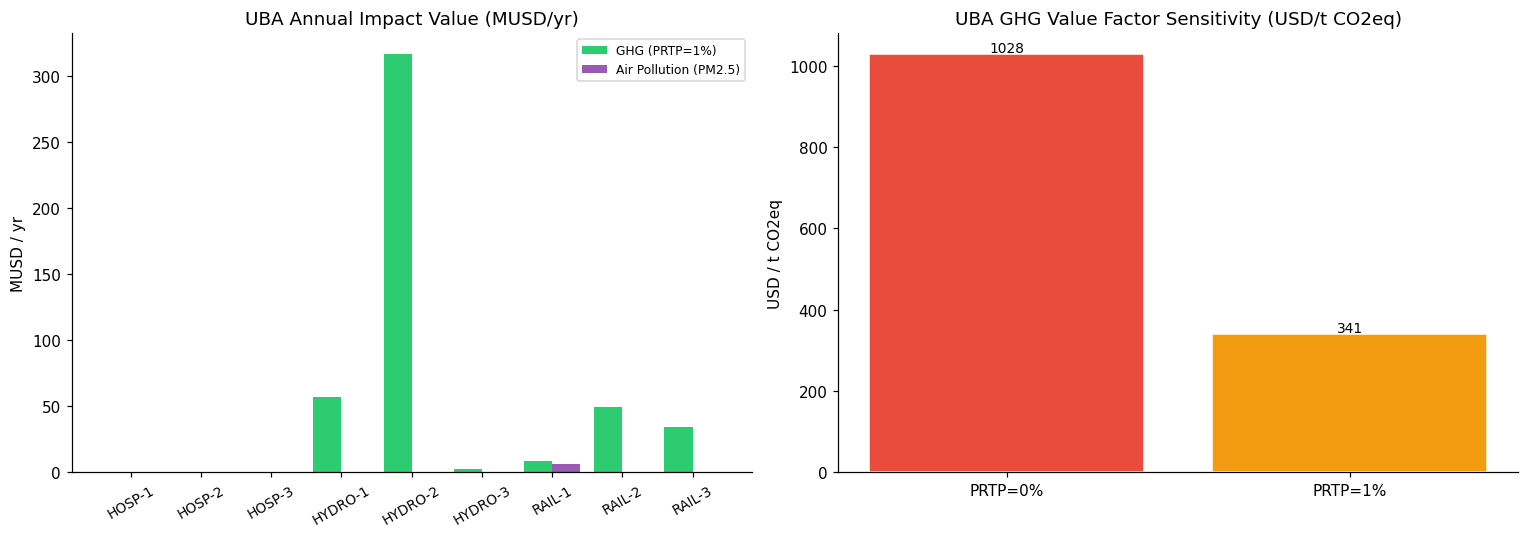

            ghg_musd_yr  ap_musd_yr  total_musd_yr
project_id                                        
HOSP-1            0.000       0.000          0.000
HOSP-2            0.000       0.000          0.000
HOSP-3            0.000       0.000          0.000
HYDRO-1          56.925       0.000         56.925
HYDRO-2         316.586       0.000        316.586
HYDRO-3           2.325       0.000          2.325
RAIL-1            8.867       6.346         15.213
RAIL-2           49.335       0.000         49.335
RAIL-3           34.155       0.000         34.155


In [10]:
# ── Load UBA coefficient files ────────────────────────────────────────────────
uba_ghg = pd.read_csv(VF_UBA / "01_uba4_ghg.csv")
uba_air = pd.read_csv(VF_UBA / "02_uba4_air_pollutants.csv")
uba_trp = pd.read_csv(VF_UBA / "07_uba4_transport_pkm_tkm.csv")

# GHG: PRTP=1% → 310 EUR_2025/t; PRTP=0% → 935 EUR_2025/t
# Use emission_year=2025 — the reference year for this assessment
uba_ghg_central = (uba_ghg[(uba_ghg.prtp_pct==1) &
                            (uba_ghg.substance=="CO2_CO2eq") &
                            (uba_ghg.emission_year==2025)]["value_factor"].values[0])
uba_ghg_high    = (uba_ghg[(uba_ghg.prtp_pct==0) &
                            (uba_ghg.substance=="CO2_CO2eq") &
                            (uba_ghg.emission_year==2025)]["value_factor"].values[0])
print(f"UBA GHG central (PRTP=1%, 2025): {uba_ghg_central} EUR_2025/t")
print(f"UBA GHG high   (PRTP=0%, 2025): {uba_ghg_high} EUR_2025/t")
print("Note: 2020 emission year values (310 / 935) are superseded by 2025 values.")

# Air: PM2.5 health damage
uba_pm25 = uba_air[(uba_air.substance=="PM2.5") & (uba_air.impact_component=="health")]
uba_pm25_val = uba_pm25.value_factor.values[0]
print(f"UBA PM2.5 health: {uba_pm25_val} EUR_2025/t")

# Convert to USD
UBA_GHG_USD  = uba_ghg_central * EUR2025_TO_USD   # USD/t
UBA_GHG_HIGH_USD = uba_ghg_high * EUR2025_TO_USD
UBA_PM25_USD = uba_pm25_val   * EUR2025_TO_USD / 1e6   # USD per kg → /1e6 for MUSD

uba_rows = []
for _, prow in monin.iterrows():
    pid = prow.project_id
    ghg_val = (prow.ghg_avoided_tco2e_yr * UBA_GHG_USD / 1e6
               if pd.notna(prow.ghg_avoided_tco2e_yr) else 0.0)
    ap_bens = prow.pollution_beneficiaries if pd.notna(prow.pollution_beneficiaries) else 0
    PM_RATE  = 3e-4   # t PM2.5 / person-year avoided
    ap_val = ap_bens * PM_RATE * uba_pm25_val * EUR2025_TO_USD / 1e6
    uba_rows.append(dict(project_id=pid, sector=prow.sector, region=prow.region,
                         ghg_musd_yr=ghg_val, ap_musd_yr=ap_val,
                         total_musd_yr=ghg_val+ap_val))

uba_df = pd.DataFrame(uba_rows)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(uba_df))
ax1.bar(x-0.2, uba_df.ghg_musd_yr, width=0.4, color="#2ecc71", label="GHG (PRTP=1%)")
ax1.bar(x+0.2, uba_df.ap_musd_yr,  width=0.4, color="#9b59b6", label="Air Pollution (PM2.5)")
ax1.set_xticks(x); ax1.set_xticklabels(uba_df.project_id, rotation=30, fontsize=9)
ax1.set_ylabel("MUSD / yr"); ax1.set_title("UBA Annual Impact Value (MUSD/yr)"); ax1.legend(fontsize=8)

# GHG sensitivity: PRTP=0% vs 1% vs 3%
uba_prtp_vals = {}
for prtp in [0, 1, 2, 3]:
    row = uba_ghg[(uba_ghg.prtp_pct==prtp) & (uba_ghg.substance=="CO2_CO2eq") &
                  (uba_ghg.emission_year==2020)]
    if not row.empty:
        uba_prtp_vals[f"PRTP={prtp}%"] = row.value_factor.values[0] * EUR2025_TO_USD
rates = list(uba_prtp_vals.keys())
vals  = list(uba_prtp_vals.values())
ax2.bar(rates, vals, color=["#e74c3c","#f39c12","#3498db","#27ae60"], edgecolor="white")
ax2.set_title("UBA GHG Value Factor Sensitivity (USD/t CO2eq)")
ax2.set_ylabel("USD / t CO2eq")
for i, v in enumerate(vals):
    ax2.text(i, v+5, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1b2_uba.png", bbox_inches="tight", dpi=130)
plt.show()
print(uba_df[["project_id","ghg_musd_yr","ap_musd_yr","total_musd_yr"]].set_index("project_id").round(3))


**UBA Methodology — DATA STATUS: CURRENT** *(Methodological Convention 4.0, December 2025)*

The German Federal Environment Agency (UBA) publishes standardised environmental value factors —
the official German regulatory reference for cost-benefit analysis of environmental policy measures.
MC 4.0 is the latest edition, published December 2025 (Eser, Matthey, Bünger 2025).

**GHG model: GIVE (Greenhouse Impact Value Estimator), Anthoff 2025** — an open-source IAM
successor to FUND, with equity weighting using German per-capita income as the reference,
covering 2020–2050 emission years for CO₂, CH₄, and N₂O (no GWP100 proxy required).

| Impact category | Basis | Key parameters |
|-----------------|-------|----------------|
| GHG (CO₂, CH₄, N₂O, F-gases) | GIVE model damage cost; monotonically rising with emission year | PRTP 0 % and 1 %; EUR_2025/t |
| PM₂.₅ / PM₁₀ | Health damage (mortality VOLY + morbidity) + crop + material; EcoSenseWeb v1.3 | EUR_2025/t |
| NOₓ, SO₂, NH₃ | Secondary particle formation + direct effects; Chen & Hoek 2020 PM CRF | EUR_2025/t |
| Electricity / Heat | Full life-cycle GHG + air pollutants; five-component structure | EUR-cent_2025/kWh |
| Transport (veh-km, pkm) | Infrastructure + exhaust + abrasion + energy supply (noise separate) | EUR_2025/veh-km |
| Noise | WHO dose-response (Guski et al. 2017); annoyance + sleep disturbance | EUR_2025/person/yr |

**GHG reference values for 2025 emission year (Table 1, MC 4.0):**
- PRTP=1%: **345 EUR_2025/t** (standard for policy evaluation; values rise with emission year)
- PRTP=0%: **990 EUR_2025/t** (equal intergenerational weighting — future damages equal to present)
- Note: 2020 emission year values (310 / 935 EUR/t) are *lower* — use 2025 values for a 2025 assessment.

Air pollutant factors are Germany-specific (EcoSenseWeb v1.3, German receptor data). GHG values
are global social cost with no regional disaggregation. All values expressed in **EUR_2025** price level.

Source: Eser N., Matthey A., Bünger B. (2025). *Handbook on Environmental Value Factors. MC 4.0.*
UBA. ISSN 2363-832X. `tvp4/uba-value-factors/METHODOLOGY.md`


#### 1B-3 · CE Delft Value Factors (Environmental Prices Handbook EU27)

CE Delft air pollutant central values (EUR_2021/kg):
  CO2     : 0.130 EUR/kg = 153.4 USD/t
  PM2.5   : 81.200 EUR/kg = 95816.0 USD/t
  PM10    : 44.300 EUR/kg = 52274.0 USD/t
  NOx     : 19.300 EUR/kg = 22774.0 USD/t
  SO2     : 26.600 EUR/kg = 31388.0 USD/t


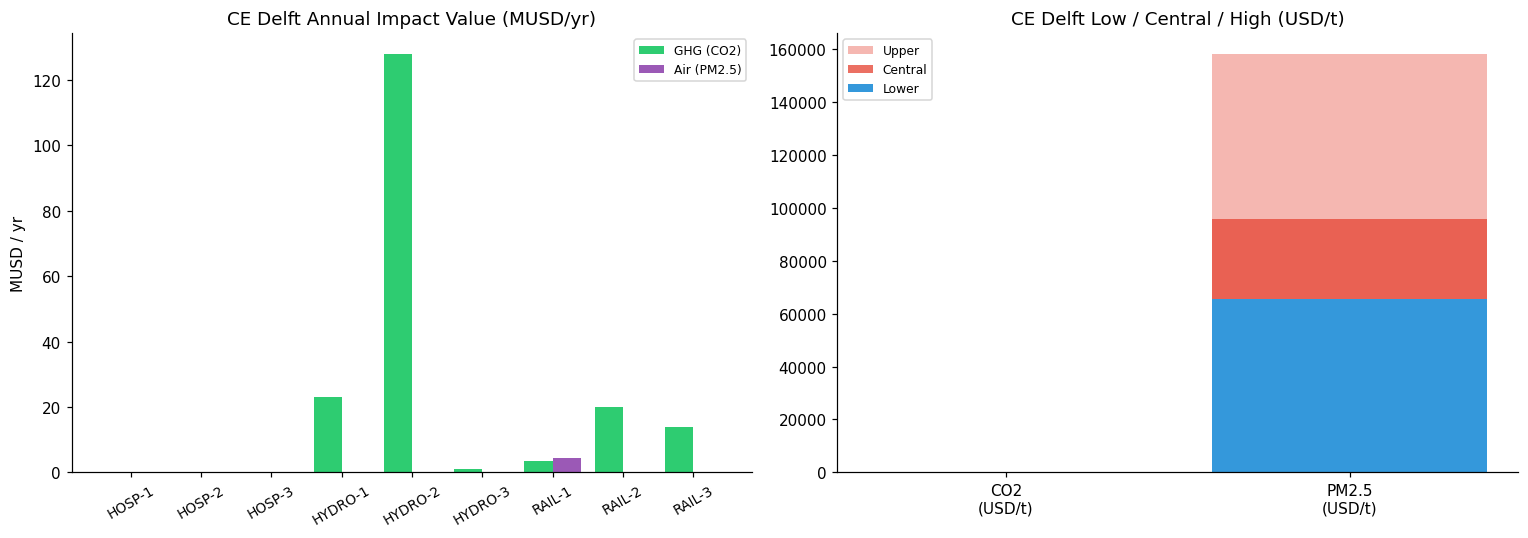

            ghg_musd_yr  ap_musd_yr  total_musd_yr
project_id                                        
HOSP-1            0.000       0.000          0.000
HOSP-2            0.000       0.000          0.000
HOSP-3            0.000       0.000          0.000
HYDRO-1          23.010       0.000         23.010
HYDRO-2         127.969       0.000        127.969
HYDRO-3           0.940       0.000          0.940
RAIL-1            3.584       4.312          7.896
RAIL-2           19.942       0.000         19.942
RAIL-3           13.806       0.000         13.806


In [11]:
# ── Load CE Delft files ───────────────────────────────────────────────────────
ced_air  = pd.read_csv(VF_CEDELFT / "01_cedelft_air_pollutants.csv")
ced_water= pd.read_csv(VF_CEDELFT / "02_cedelft_water_pollutants.csv")
ced_land = pd.read_csv(VF_CEDELFT / "04_cedelft_land_use.csv")

# Extract central values for key pollutants (EUR_2021/kg)
def ced_val(df, name_substr, col="central"):
    row = df[df.pollutant_name.str.contains(name_substr, case=False, na=False)]
    return float(row[col].values[0]) if not row.empty else np.nan

ced_co2_eur   = ced_val(ced_air,  "Carbon dioxide")          # EUR_2021/kg
ced_pm25_eur  = ced_val(ced_air,  "Particulate matter <2.5") # EUR_2021/kg
ced_pm10_eur  = ced_val(ced_air,  "Particulate matter <10")
ced_nox_eur   = ced_val(ced_air,  "Nitrogen oxides")
ced_so2_eur   = ced_val(ced_air,  "Sulphur dioxide")

print("CE Delft air pollutant central values (EUR_2021/kg):")
for n, v in [("CO2",ced_co2_eur),("PM2.5",ced_pm25_eur),("PM10",ced_pm10_eur),
             ("NOx",ced_nox_eur),("SO2",ced_so2_eur)]:
    print(f"  {n:<8}: {v:.3f} EUR/kg = {v*EUR2021_TO_USD*1000:.1f} USD/t")

CED_CO2_USD   = ced_co2_eur  * EUR2021_TO_USD * 1000   # USD/t CO2
CED_PM25_USD  = ced_pm25_eur * EUR2021_TO_USD * 1000   # USD/t PM2.5

ced_rows = []
for _, prow in monin.iterrows():
    pid = prow.project_id
    ghg_val = (prow.ghg_avoided_tco2e_yr * CED_CO2_USD / 1e6
               if pd.notna(prow.ghg_avoided_tco2e_yr) else 0.0)
    ap_bens = prow.pollution_beneficiaries if pd.notna(prow.pollution_beneficiaries) else 0
    PM_RATE = 3e-4
    ap_val  = ap_bens * PM_RATE * CED_PM25_USD / 1e6
    ced_rows.append(dict(project_id=pid, sector=prow.sector, region=prow.region,
                         ghg_musd_yr=ghg_val, ap_musd_yr=ap_val,
                         total_musd_yr=ghg_val+ap_val))

ced_df = pd.DataFrame(ced_rows)

# Low / central / high range for CO2 and PM2.5
ced_range = {
    "CO2":   {"low": ced_val(ced_air,"Carbon dioxide","lower"),
               "central": ced_co2_eur,
               "high": ced_val(ced_air,"Carbon dioxide","upper")},
    "PM2.5": {"low": ced_val(ced_air,"Particulate matter <2.5","lower"),
               "central": ced_pm25_eur,
               "high": ced_val(ced_air,"Particulate matter <2.5","upper")},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(ced_df))
ax1.bar(x-0.2, ced_df.ghg_musd_yr, width=0.4, color="#2ecc71", label="GHG (CO2)")
ax1.bar(x+0.2, ced_df.ap_musd_yr,  width=0.4, color="#9b59b6", label="Air (PM2.5)")
ax1.set_xticks(x); ax1.set_xticklabels(ced_df.project_id, rotation=30, fontsize=9)
ax1.set_ylabel("MUSD / yr"); ax1.set_title("CE Delft Annual Impact Value (MUSD/yr)")
ax1.legend(fontsize=8)

polls = list(ced_range.keys())
lows  = [ced_range[p]["low"]*EUR2021_TO_USD*1000 for p in polls]
cents = [ced_range[p]["central"]*EUR2021_TO_USD*1000 for p in polls]
highs = [ced_range[p]["high"]*EUR2021_TO_USD*1000 for p in polls]
xs = np.arange(len(polls))
ax2.bar(xs, highs, color="#e74c3c", alpha=0.4, label="Upper")
ax2.bar(xs, cents, color="#e74c3c", alpha=0.8, label="Central")
ax2.bar(xs, lows,  color="#3498db", label="Lower")
ax2.set_xticks(xs); ax2.set_xticklabels([f"{p}\n(USD/t)" for p in polls])
ax2.set_title("CE Delft Low / Central / High (USD/t)"); ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1b3_cedelft.png", bbox_inches="tight", dpi=130)
plt.show()
print(ced_df[["project_id","ghg_musd_yr","ap_musd_yr","total_musd_yr"]].set_index("project_id").round(3))


**CE Delft Methodology — DATA STATUS: CURRENT methodology; ⚠️ EUR_2021 price base (3-year lag)**
*(Environmental Prices Handbook 2024: EU27 version, v1.1, April 2025)*

CE Delft derives **environmental prices** as societal welfare-loss per emission unit through a
**three-level Impact Pathway Approach (IPA)**:

```
LEVEL 1 — INTERVENTIONS  → emissions to air / water / soil
LEVEL 2 — MIDPOINTS       → climate change, PM formation, eutrophication, ecotoxicity, …
LEVEL 3 — ENDPOINTS       → human health (VOLY/VSL), ecosystem services, materials, resources
```

**Dispersion models:** EEA/GAINS 2021 SHERPA (22×33 km grid; NO₂ at 1×1 km resolution).
**Dose-response:** Chen & Hoek (2020) for PM₂.₅ mortality; WHO HRAPIE (2013) for NO₂/O₃.

| Category | Method | Coverage |
|----------|--------|---------|
| CO₂ | IPA damage cost (not EU ETS); low/central/high | EUR_2021/kg |
| PM₂.₅ / PM₁₀ | VOLY = **€85,000/VOLY** (central, 2021); morbidity + crop + material | EUR_2021/kg |
| NOₓ, SO₂, NH₃ | Secondary PM formation + direct health effects | EUR_2021/kg |
| Water pollutants | Eutrophication (N, P) + ecotoxicity; 22 substances × 2 water bodies | EUR_2021/kg |
| Land use | Biodiversity loss (50-yr horizon); central **€0.053/m²/yr** | EUR_2021/m²/yr |
| Soil pollutants | Human health + ecosystem; 21 substances | EUR_2021/kg |
| LCA midpoints | ReCiPe 2016 H + PEF (CAT I/II); 19 impact categories | EUR_2021/unit |
| Secondary pollutants | 3,000+ substances via ReCiPe characterisation factors | EUR_2021/unit |

**Three uncertainty variants** (lower / central / upper) from income elasticity 0.3/0.65/1.0 and CRF
assumptions, suitable for SCBA sensitivity bounds.

⚠️ **Price base note:** Values are in **EUR_2021**. The handbook was published April 2025, making the
price base 3–4 years behind current price levels. A temporal value transfer using HICP inflation
(`VF(t) = VF(2021) × HICP(t)/HICP(2021)`) is recommended for current assessments. An indicative
EUR_2021→USD conversion rate of 1.18 is applied here — results are order-of-magnitude only.

**Geographic scope:** EU27 average values. Value transfer required for non-EU application
(`VF_country = VF_EU27 × (GNI_country / GNI_EU27)^ε`, ε = 0.3–1.0 by variant). Not applied here —
non-EU project results should be treated as upper-bound estimates.

Source: De Vries et al. (2025). *Environmental Prices Handbook 2024: EU27 version* (v1.1, Ref. 230107).
CE Delft. `tvp4/cedelft-value-factors/METHODOLOGY.md`


#### 1B-4 · UK Wellbeing Value Factors (HM Treasury Green Book / WELLBY)

WELLBY: 10000.0–13000.0–16000.0 GBP_2019/WELLBY
       = 16640 USD (central) at 1.28 GBP/USD

UK health per person sample (Frontier/DCMS Dec 2024, GBP_2024):
                                    engagement_type              health_outcome  total_per_person                 unit
Museum, gallery, heritage, cinema, theatre, concert              General health               992 GBP_2024/person/year
                        General cultural attendance   Mental health functioning               649 GBP_2024/person/year
                       Arts & culture participation   Mental health functioning               448 GBP_2024/person/year
         Dance, music, art, performing arts classes Emotional regulation / ADHD               122 GBP_2024/person/year
Note: WELLBY unit value is GBP_2019; Frontier data GBP_2024 — mixed price base.
No cross-deflation applied — results are indicative order-of-magnitude only.


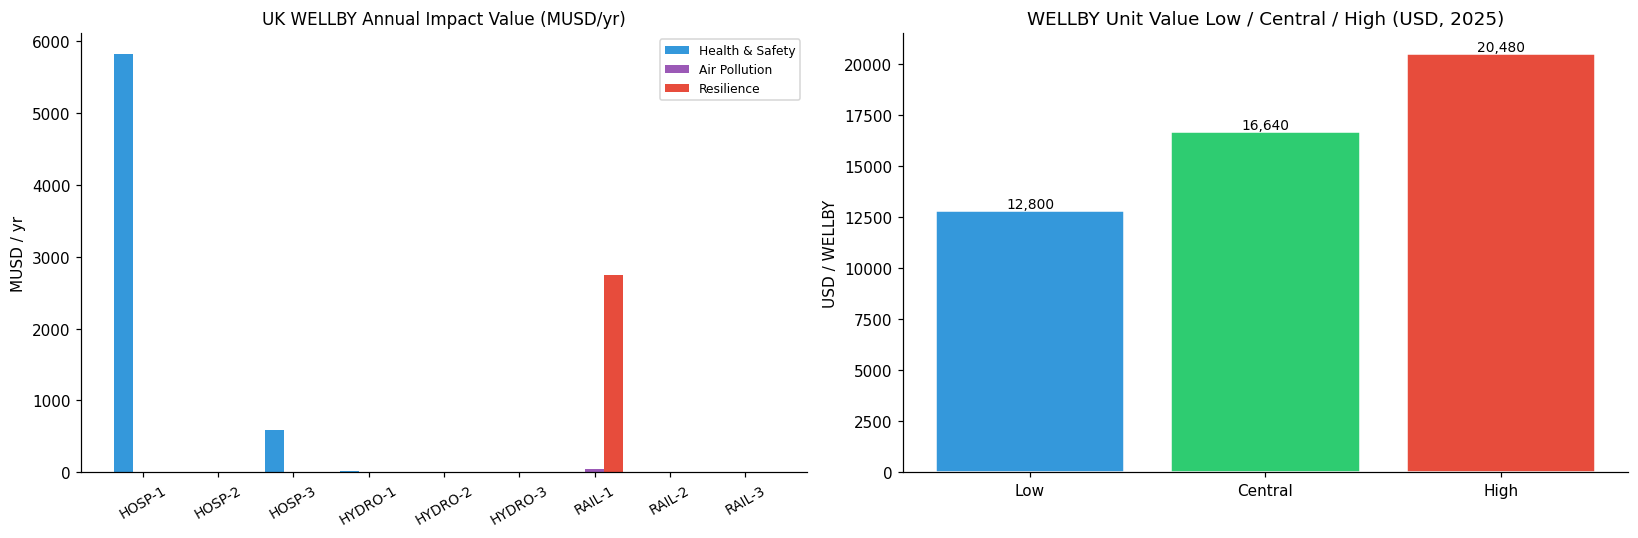

            hs_musd_yr  ap_musd_yr  res_musd_yr  total_musd_yr
project_id                                                    
HOSP-1       5,824.000       0.000        0.000      5,824.000
HOSP-2           3.494       0.000        0.000          3.494
HOSP-3         582.400       0.000        0.000        582.400
HYDRO-1         17.472       0.000        0.000         17.472
HYDRO-2          0.000       0.000        0.000          0.000
HYDRO-3          0.000       0.000        0.000          0.000
RAIL-1           0.000      49.920    2,745.600      2,795.520
RAIL-2           0.000       0.000        0.000          0.000
RAIL-3           0.000       0.000        0.000          0.000


In [12]:
# ── Load UK Wellbeing files ───────────────────────────────────────────────────
uk_wellby = pd.read_csv(VF_UK / "01_uk_wellby_valuations.csv")
uk_health = pd.read_csv(VF_UK / "03_uk_culture_health_per_person.csv")
uk_work   = pd.read_csv(VF_UK / "05_uk_workplace_wellbeing.csv")

# WELLBY central value
wellby_central = uk_wellby[(uk_wellby.value_factor=="WELLBY") &
                            (uk_wellby.variant=="central")]["value"].values[0]
wellby_low     = uk_wellby[(uk_wellby.value_factor=="WELLBY") &
                            (uk_wellby.variant=="low")]["value"].values[0]
wellby_high    = uk_wellby[(uk_wellby.value_factor=="WELLBY") &
                            (uk_wellby.variant=="high")]["value"].values[0]

# Convert GBP_2019 → USD_2025
WELLBY_USD = wellby_central * GBP2019_TO_USD
print(f"WELLBY: {wellby_low}–{wellby_central}–{wellby_high} GBP_2019/WELLBY")
print(f"       = {wellby_central*GBP2019_TO_USD:.0f} USD (central) at {GBP2019_TO_USD} GBP/USD")

# Health per person — Frontier Economics / DCMS December 2024 (GBP_2024)
print("\nUK health per person sample (Frontier/DCMS Dec 2024, GBP_2024):")
print(uk_health.head(4)[["engagement_type","health_outcome","total_per_person","unit"]].to_string(index=False))
print("Note: WELLBY unit value is GBP_2019; Frontier data GBP_2024 — mixed price base.")
print("No cross-deflation applied — results are indicative order-of-magnitude only.")

WELLBY_HEALTH_IMPROVEMENT = 0.07  # WELLBY/person-year for significant H&S improvement
WELLBY_DISCOUNT = 0.035           # UK STPR (Green Book 2026)

uk_rows = []
for _, prow in monin.iterrows():
    pid  = prow.project_id
    bens = prow.health_beneficiaries if pd.notna(prow.health_beneficiaries) else 0
    hs_val = bens * WELLBY_HEALTH_IMPROVEMENT * WELLBY_USD / 1e6   # MUSD/yr

    # Air pollution: 0.02 WELLBY lost per person-year affected → improvement = 0.02 WELLBY
    ap_bens = prow.pollution_beneficiaries if pd.notna(prow.pollution_beneficiaries) else 0
    ap_val  = ap_bens * 0.02 * WELLBY_USD / 1e6

    # Resilience: 0.03 WELLBY improvement per beneficiary-year
    res_bens = prow.resilience_beneficiaries if pd.notna(prow.resilience_beneficiaries) else 0
    res_val  = res_bens * 0.03 * WELLBY_USD / 1e6

    uk_rows.append(dict(project_id=pid, sector=prow.sector, region=prow.region,
                        hs_musd_yr=hs_val, ap_musd_yr=ap_val, res_musd_yr=res_val,
                        total_musd_yr=hs_val+ap_val+res_val))

uk_df = pd.DataFrame(uk_rows)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(uk_df))
w = 0.25
ax.bar(x-w, uk_df.hs_musd_yr,  width=w, color="#3498db", label="Health & Safety")
ax.bar(x,   uk_df.ap_musd_yr,  width=w, color="#9b59b6", label="Air Pollution")
ax.bar(x+w, uk_df.res_musd_yr, width=w, color="#e74c3c", label="Resilience")
ax.set_xticks(x); ax.set_xticklabels(uk_df.project_id, rotation=30, fontsize=9)
ax.set_ylabel("MUSD / yr"); ax.set_title("UK WELLBY Annual Impact Value (MUSD/yr)", fontsize=11)
ax.legend(fontsize=8)

variants = ["Low", "Central", "High"]
vals_usd  = [wellby_low * GBP2019_TO_USD,
             wellby_central * GBP2019_TO_USD,
             wellby_high * GBP2019_TO_USD]
ax2.bar(variants, vals_usd, color=["#3498db","#2ecc71","#e74c3c"], edgecolor="white")
ax2.set_title("WELLBY Unit Value Low / Central / High (USD, 2025)")
ax2.set_ylabel("USD / WELLBY")
for i, v in enumerate(vals_usd):
    ax2.text(i, v + 150, f"{v:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(PA_DIR / "fig_1b4_uk_wellby.png", bbox_inches="tight", dpi=130)
plt.show()
print(uk_df[["project_id","hs_musd_yr","ap_musd_yr","res_musd_yr","total_musd_yr"]].set_index("project_id").round(3))


**UK Wellbeing / WELLBY Methodology — DATA STATUS: CURRENT** *(Green Book 2026; WELLBY Guidance 2021)*

The **WELLBY** (Wellbeing-Adjusted Life Year) is the primary unit in HM Treasury's framework for
monetising subjective wellbeing impacts in UK public sector appraisal (Green Book 2026).

One WELLBY = a change of **one point on the 0–10 life satisfaction scale** for one person for one year.

| Parameter | Value | Derivation |
|-----------|-------|-----------|
| WELLBY central | **£13,000 GBP_2019/WELLBY** | Midpoint of QALY-based and income-based estimates |
| WELLBY low | £10,000 GBP_2019/WELLBY | QALY-based: £70,158/QALY ÷ 7 LS-points/QALY (Frijters & Krekel 2021) |
| WELLBY high | £16,000 GBP_2019/WELLBY | Income-based: £30,673 avg. earnings ÷ 1.96 log-income coefficient |
| QALY (welfare) | £70,000 GBP_2019/QALY | Green Book; relationship: 1 QALY ≈ 7 WELLBYs |
| Social discount rate (STPR) | 3.5% (years 1–30), 3.0% (31–75), 2.5% (76+) | Green Book Ramsey formula |
| Health/wellbeing discount rate | 1.5% (years 0–30) | Intergenerational equity adjustment |

**Uprating formula:** `WELLBY(t) = WELLBY(2019) × GDP_deflator(t)/GDP_deflator(2019) × (GDP_pc(t)/GDP_pc(2019))^1.3`
where 1.3 is the marginal utility of income elasticity (Green Book Annex 3).

⚠️ **Mixed price base warning:** WELLBY unit value is **GBP_2019** (Wellbeing Guidance 2021) while
Frontier Economics culture/health data is **GBP_2024** (Frontier 2024 for DCMS). No cross-deflation
is applied in this assessment — results are indicative order-of-magnitude estimates only.

**Scope and limitations for this assessment:**
- WELLBY is calibrated for UK/OECD populations. Applying to Nigeria (HOSP-2, HYDRO-1) without
  a geographic income transfer (`WELLBY_country = WELLBY_UK × (GDPpc_country/GDPpc_UK)^ε`) overstates
  absolute values — treat non-UK results as upper bounds.
- GHG is not valued through WELLBY (uses SCC instead); only health, air quality, and resilience
  pathways are monetised here. Indicative conversion at GBP_2019 → USD: 1.28.

Sources:
- HM Treasury (2026). *The Green Book.* OGL v3.
- HM Treasury (2021). *Wellbeing Guidance for Appraisal* (supplementary Green Book guidance).
- Frontier Economics / DCMS (2024). *Health and Wellbeing Final Report.* (GBP_2024)
- OECD (2025). *The WELLBY Well-being Valuation Method in the UK* (60c1396c-en).
`tvp4/uk-value-factors/METHODOLOGY.md`


#### 1B-5 · EPS Value Factors (Environmental Priority Strategies)

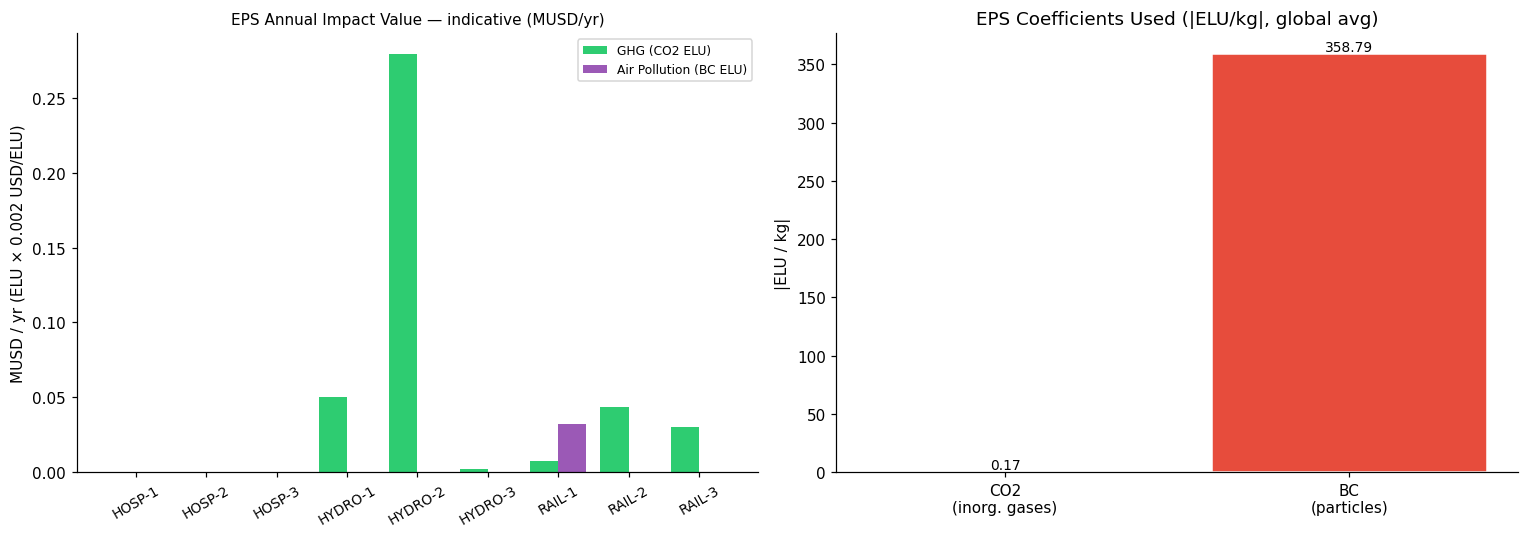

ELU-to-USD: indicative only. EPS values are global substance averages.
            ghg_musd_yr  ap_musd_yr  total_musd_yr
project_id                                        
HOSP-1            0.000       0.000          0.000
HOSP-2            0.000       0.000          0.000
HOSP-3            0.000       0.000          0.000
HYDRO-1           0.050       0.000          0.050
HYDRO-2           0.279       0.000          0.279
HYDRO-3           0.002       0.000          0.002
RAIL-1            0.008       0.032          0.040
RAIL-2            0.043       0.000          0.043
RAIL-3            0.030       0.000          0.030


In [13]:
# ── EPS coefficients (global averages, Steen 2015 — ELU/kg) ─────────────────
# EPS uses Environmental Load Units (ELU); coverage limited to AFG/AGO/ALB in
# this extract; Steen 2015 global averages are used as universal proxies.
ELU_TO_USD = 0.002            # indicative: 1 ELU ≈ 0.002 USD (Steen 2015)
EPS_BC_ELU_PER_KG  = 358.79  # |ELU/kg| black carbon to air (global avg, 2023)
EPS_CO2_ELU_PER_KG = 0.1673  # |ELU/kg| CO2 to air (inorganic gases, 2023)

PM_RATE_KG = 0.30  # kg PM2.5-eq / person-year avoided

eps_rows = []
for _, prow in monin.iterrows():
    pid = prow.project_id
    ap_bens = prow.pollution_beneficiaries if pd.notna(prow.pollution_beneficiaries) else 0
    ap_elu  = ap_bens * PM_RATE_KG * EPS_BC_ELU_PER_KG
    ap_val  = ap_elu * ELU_TO_USD / 1e6

    ghg_val = 0.0
    if pd.notna(prow.ghg_avoided_tco2e_yr):
        ghg_elu = prow.ghg_avoided_tco2e_yr * 1000 * EPS_CO2_ELU_PER_KG
        ghg_val = ghg_elu * ELU_TO_USD / 1e6

    eps_rows.append(dict(project_id=pid, sector=prow.sector, region=prow.region,
                         ghg_musd_yr=ghg_val, ap_musd_yr=ap_val,
                         total_musd_yr=ghg_val+ap_val))

eps_df = pd.DataFrame(eps_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(eps_df))
ax1.bar(x-0.2, eps_df.ghg_musd_yr, width=0.4, color="#2ecc71", label="GHG (CO2 ELU)")
ax1.bar(x+0.2, eps_df.ap_musd_yr,  width=0.4, color="#9b59b6", label="Air Pollution (BC ELU)")
ax1.set_xticks(x); ax1.set_xticklabels(eps_df.project_id, rotation=30, fontsize=9)
ax1.set_ylabel("MUSD / yr (ELU × 0.002 USD/ELU)")
ax1.set_title("EPS Annual Impact Value — indicative (MUSD/yr)", fontsize=10)
ax1.legend(fontsize=8)

eps_substances = {"CO2\n(inorg. gases)": EPS_CO2_ELU_PER_KG,
                  "BC\n(particles)":      EPS_BC_ELU_PER_KG}
ax2.bar(list(eps_substances.keys()), list(eps_substances.values()),
        color=["#2ecc71","#e74c3c"], edgecolor="white")
ax2.set_title("EPS Coefficients Used (|ELU/kg|, global avg)")
ax2.set_ylabel("|ELU / kg|")
for i, v in enumerate(eps_substances.values()):
    ax2.text(i, v+3, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1b5_eps.png", bbox_inches="tight", dpi=130)
plt.show()
print("ELU-to-USD: indicative only. EPS values are global substance averages.")
print(eps_df[["project_id","ghg_musd_yr","ap_musd_yr","total_musd_yr"]].set_index("project_id").round(4))


**EPS Methodology — ⚠️ DATA STATUS: OUTDATED** *(EPS 2015d.1, Steen 2015 — 10+ year old methodology)*

> **This value factor system is based on EPS 2015d.1 (Steen 2015), which is over 10 years old.
> No newer EPS version has been published as of April 2026. Results are included for completeness
> and methodological breadth, but should NOT be used as a primary basis for decision-making.
> They are provided as a relative priority score comparison only.**

The EPS (Environmental Priority Strategies) system, originally developed by Steen (1999) and
updated in 2015, assigns **Environmental Load Units (ELU)** to emissions and resource use
based on their contribution to five **safeguard subjects**. 1 ELU ≈ 1 EUR of welfare loss
(2015 price level).

| Safeguard Subject | Description | Key substances |
|-------------------|-------------|---------------|
| Human Health | YOLL (years of life lost), working capacity, disease burdens | PM₂.₅, BC, SO₂, NOₓ, heavy metals |
| Ecosystem Services | Provisioning (food, wood, water) + cultural services | SO₂ (acidification), NOₓ, pesticides |
| Biodiversity | Species extinction equivalents (NEX) | Land use, water pollutants |
| Abiotic Resources | Depletion valued by production-cost differential | Fossil fuels, metals, phosphorus |
| Economic Assets | Technology infrastructure capacity | Construction pollutants |

**Coefficient formula:** `C = Sign × EPS_index[substance] × HICP_inflation_factor`

- All coefficients are **globally uniform** — no country or sector variation (unlike WifOR/eQALY).
  The 189-country structure is maintained only for MRIO framework compatibility.
- Inflation adjustment uses EU HICP (base 2015 = 100); frozen at 2023 value for future years.
- Values used here (global averages from AFG column = all columns): CO₂ = 0.1673 ELU/kg;
  Black Carbon = 358.79 ELU/kg.
- **ELU→USD conversion (0.002 USD/ELU) is highly uncertain** — intended as a relative priority
  score, not an absolute monetary value. Use alongside other VF systems for triangulation.

**Known limitations:**
- Uncertainty factors up to **3× (NEX pathway)** — very wide ranges for biodiversity-related impacts.
- YOLL/state indicator values derived from early 2000s WTP/WHO data, not updated since 2015.
- No country-specific damage costs (all global averages).

Source: Steen, B. (2015). *EPS 2015d.1 — Including climate impacts from secondary particles.*
Swedish Life Cycle Center Report 2015:4a. Chalmers University of Technology. `tvp4/stockholm-value-factors/METHODOLOGY.md`


#### 1B-6 · eQALY / Valuing Impact Value Factors

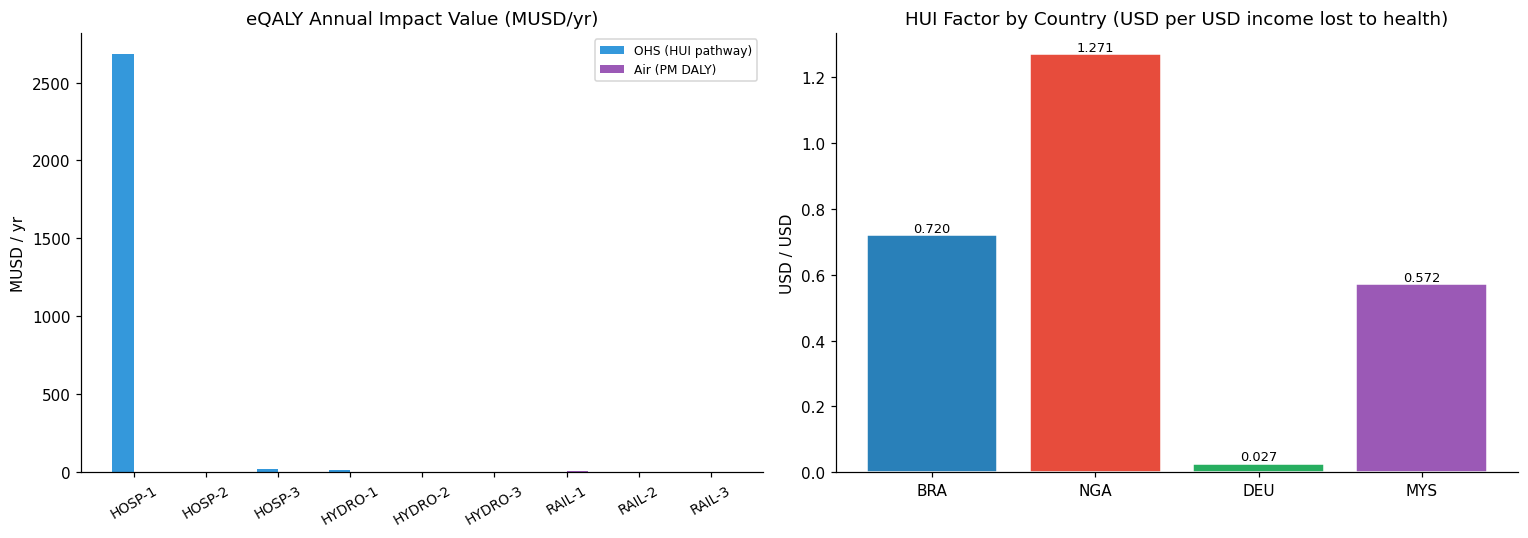

            hs_hui_musd_yr  ap_musd_yr  total_musd_yr  hui_factor
project_id                                                       
HOSP-1           2,682.344       0.000      2,682.344       0.720
HOSP-2               3.442       0.000          3.442       1.271
HOSP-3              22.292       0.000         22.292       0.027
HYDRO-1             17.209       0.000         17.209       1.271
HYDRO-2              0.000       0.000          0.000       0.572
HYDRO-3              0.000       0.000          0.000       0.027
RAIL-1               0.000       9.673          9.673       0.027
RAIL-2               0.000       0.000          0.000       0.027
RAIL-3               0.000       0.000          0.000       0.027


In [14]:
# ── Load eQALY files ──────────────────────────────────────────────────────────
eq_hui   = pd.read_csv(VF_EQALY / "01_eqaly_hui.csv")
eq_daly  = pd.read_csv(VF_EQALY / "04_eqaly_health_daly.csv")
eq_wages = pd.read_csv(VF_EQALY / "03_eqaly_wages.csv")

# HUI: Human Capital Income approach — USD value of lost health per USD of labor income
# hui_usd_per_usd = USD of health-economic loss per USD of worker income
# We use it as: benefit = beneficiaries × annual_wage × hui_factor_improvement

# DALY: occupational injuries / PM occupational for each project country
def eq_hui_lookup(country_iso):
    row = eq_hui[eq_hui.country_code == country_iso]
    if row.empty: return np.nan, np.nan
    return float(row.hui_usd_per_usd.values[0]), float(row.living_wage_usd_year.values[0])

def eq_daly_lookup(country_iso, risk_key):
    row = eq_daly[(eq_daly.country_code==country_iso) &
                  (eq_daly.risk_factor_key.str.contains(risk_key, case=False, na=False))]
    if row.empty: return np.nan
    return float(row.daly_per_capita.values[0])

# VSL from DALY: convert to monetary via CHE (current health expenditure per capita)
# VSL proxy = CHE / DALY rate (country-specific willingness-to-pay for health)

INCOME_ADJ = {"BRA": 7447, "NGA": 9026, "DEU": 16683, "MYS": 7248}  # living wage USD/yr

eqaly_rows = []
for _, prow in monin.iterrows():
    pid = prow.project_id
    iso, nace = PROJ_VF_MAP[pid]
    hui_factor, wage = eq_hui_lookup(iso)
    daly_injury = eq_daly_lookup(iso, "ohs_occupational_injuries")
    daly_pm     = eq_daly_lookup(iso, "ohs_occupational_pm")

    bens = prow.health_beneficiaries if pd.notna(prow.health_beneficiaries) else 0
    wage = INCOME_ADJ.get(iso, 7500)

    # ── eQALY core formula: Footprint × DALY_VALUE ──────────────────────────
    # DALY_VALUE = 59,446 USD/DALY (OECD GDP/capita 2023, current PPP)
    # Source: eQALY_Template_2025-02-14_EXPORT.xlsx > Parameters | VI sheet
    EQALY_DALY_VALUE = 59_446  # USD/DALY — DO NOT replace with VSL proxy

    # OHS via HUI (Human Capital Income pathway):
    # Footprint = beneficiaries × HUI_factor × HUI_improvement_fraction
    HUI_IMPROVEMENT = 0.10   # fraction of HUI burden averted per person-year
    hs_val = bens * (hui_factor or 0) * HUI_IMPROVEMENT * wage / 1e6

    # OHS via DALY (Health pathway):
    # Footprint = beneficiaries × daly_per_capita; Value = Footprint × DALY_VALUE
    daly_hs = bens * (daly_injury or 0) * EQALY_DALY_VALUE / 1e6

    # Air pollution via occupational PM DALY pathway
    ap_bens = prow.pollution_beneficiaries if pd.notna(prow.pollution_beneficiaries) else 0
    ap_val  = ap_bens * (daly_pm or 0) * EQALY_DALY_VALUE / 1e6

    eqaly_rows.append(dict(project_id=pid, sector=prow.sector, region=prow.region,
                           hs_hui_musd_yr=hs_val, hs_daly_musd_yr=daly_hs,
                           ap_musd_yr=ap_val,
                           total_musd_yr=hs_val+ap_val,
                           hui_factor=hui_factor, living_wage=wage))

eqaly_df = pd.DataFrame(eqaly_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(eqaly_df))
w = 0.3
axes[0].bar(x-w/2, eqaly_df.hs_hui_musd_yr, width=w, color="#3498db", label="OHS (HUI pathway)")
axes[0].bar(x+w/2, eqaly_df.ap_musd_yr,     width=w, color="#9b59b6", label="Air (PM DALY)")
axes[0].set_xticks(x); axes[0].set_xticklabels(eqaly_df.project_id, rotation=30, fontsize=9)
axes[0].set_ylabel("MUSD / yr"); axes[0].set_title("eQALY Annual Impact Value (MUSD/yr)")
axes[0].legend(fontsize=8)

# HUI factor comparison by country
countries = ["BRA","NGA","DEU","MYS"]
hui_vals  = [eq_hui[eq_hui.country_code==c].hui_usd_per_usd.values[0] for c in countries]
cols      = ["#2980b9","#e74c3c","#27ae60","#9b59b6"]
axes[1].bar(countries, hui_vals, color=cols, edgecolor="white")
axes[1].set_title("HUI Factor by Country (USD per USD income lost to health)")
axes[1].set_ylabel("USD / USD")
for i, v in enumerate(hui_vals):
    axes[1].text(i, v+0.01, f"{v:.3f}", ha="center", fontsize=8.5)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1b6_eqaly.png", bbox_inches="tight", dpi=130)
plt.show()
print(eqaly_df[["project_id","hs_hui_musd_yr","ap_musd_yr","total_musd_yr","hui_factor"]].set_index("project_id").round(4))


**eQALY / Valuing Impact Methodology — DATA STATUS: CURRENT** *(template 2025-02-14; WIVF 2024)*

eQALY (Valuing Impact, 2025) is a **multi-capital, DALY-based framework** bridging IHME GBD 2019
disease burden data with country-specific economic valuation across four capital types:
Human, Social, Natural, and Business.

**Core valuation formula** (from Model sheet of eQALY template):
```
Footprint          = Output × Outcome_rate × Baseline × Drop-off × Attribution × Duration
Societal_valuation = Footprint × Valuation_factor
```

**Global reference parameters** (Parameters | VI sheet, eQALY template):
| Parameter | Value | Source |
|-----------|-------|--------|
| **DALY value** | **59,446 USD/DALY** | OECD GDP/capita 2023, current prices, current PPP |
| Average HUT | 0.7581 USD/USD | Valuing Impact, global average |
| Average HUI | 0.7044 USD/USD | Valuing Impact, global average |
| Reference year | 2023 | USD price base; IMF deflator for other years |

| Pathway | Capital | Metric | Country variation |
|---------|---------|--------|-----------------|
| HUI — Health Utility of Income | Human | `DALY_per_work_year[country] / living_wage[country]` | Yes — 188 countries |
| HUT — Health Utility of Taxes | Social | SROI of public health expenditure | Yes — 148 countries |
| Wages | Human | ILO income-share × GDP/capita, 3 skill tiers | Yes — 188 countries |
| Health DALY | Human | `DALY_rate[country, risk] × 59,446 USD/DALY` | Yes — 16 risk factors × 200+ countries |
| NatCap pollution (EF 3.0) | Natural | LCA midpoint × CE Delft / WRI factors | None — globally uniform |
| NatCap land (LANCA v2.0) | Natural | Ecosystem service value × HUT_avg | Yes — country-specific |

**Key parameters for this assessment:**
- **DALY value = 59,446 USD/DALY** (OECD GDP/capita 2023 PPP) — this is the actual eQALY parameter,
  NOT a VSL proxy. Apply as: `benefit_USD = n_beneficiaries × DALY_rate × 59,446`
- HUI factor: 0.027 (DEU — low disease burden, high income) → 1.271 (NGA — high disease burden, low income)
  — higher HUI means each USD of income improvement generates more societal welfare in poorer countries
- OHS DALY for occupational injuries: country-specific from IHME GBD 2019 (risk factor: `ohs_occupational_injuries`)
- NatCap pollution factors from CE Delft Environmental Prices Handbook + WRI (2023 USD)
- Price base: **USD_2023**; IMF world deflator for other years (2014–2023 varying; 2024+ frozen at 1.0)

Sources:
- Valuing Impact (2025). *eQALY_Template_2025-02-14_EXPORT.xlsx.* valuingimpact.org
- Valuing Impact (2024). *WIVF 2024 — WASH Impact Valuation Framework.*
- IHME (2019). *Global Burden of Disease 2019.* healthdata.org
`tvp4/valuingimpact-value-factors/METHODOLOGY.md`


#### 1B-7 · Cross-System Comparison — All Six Value Factor Systems

Annual impact value by value factor system (MUSD/yr):
               WifOR     UBA  CE Delft  UK WELLBY   EPS     eQALY      mean   min       max
project_id                                                                                 
HOSP-1     4,331.711   0.000     0.000  5,824.000 0.000 2,682.344 2,139.676 0.000 5,824.000
HOSP-2         2.018   0.000     0.000      3.494 0.000     3.442     1.492 0.000     3.494
HOSP-3       362.515   0.000     0.000    582.400 0.000    22.292   161.201 0.000   582.400
HYDRO-1       21.512  56.925    23.010     17.472 0.050    17.209    22.696 0.050    56.925
HYDRO-2       63.526 316.586   127.969      0.000 0.279     0.000    84.727 0.000   316.586
HYDRO-3        0.466   2.325     0.940      0.000 0.002     0.000     0.622 0.000     2.325
RAIL-1         3.711  15.213     7.896  2,795.520 0.040     9.673   472.009 0.040 2,795.520
RAIL-2         9.899  49.335    19.942      0.000 0.043     0.000    13.203 0.000    49.335
RAIL-3         6.853  34.1

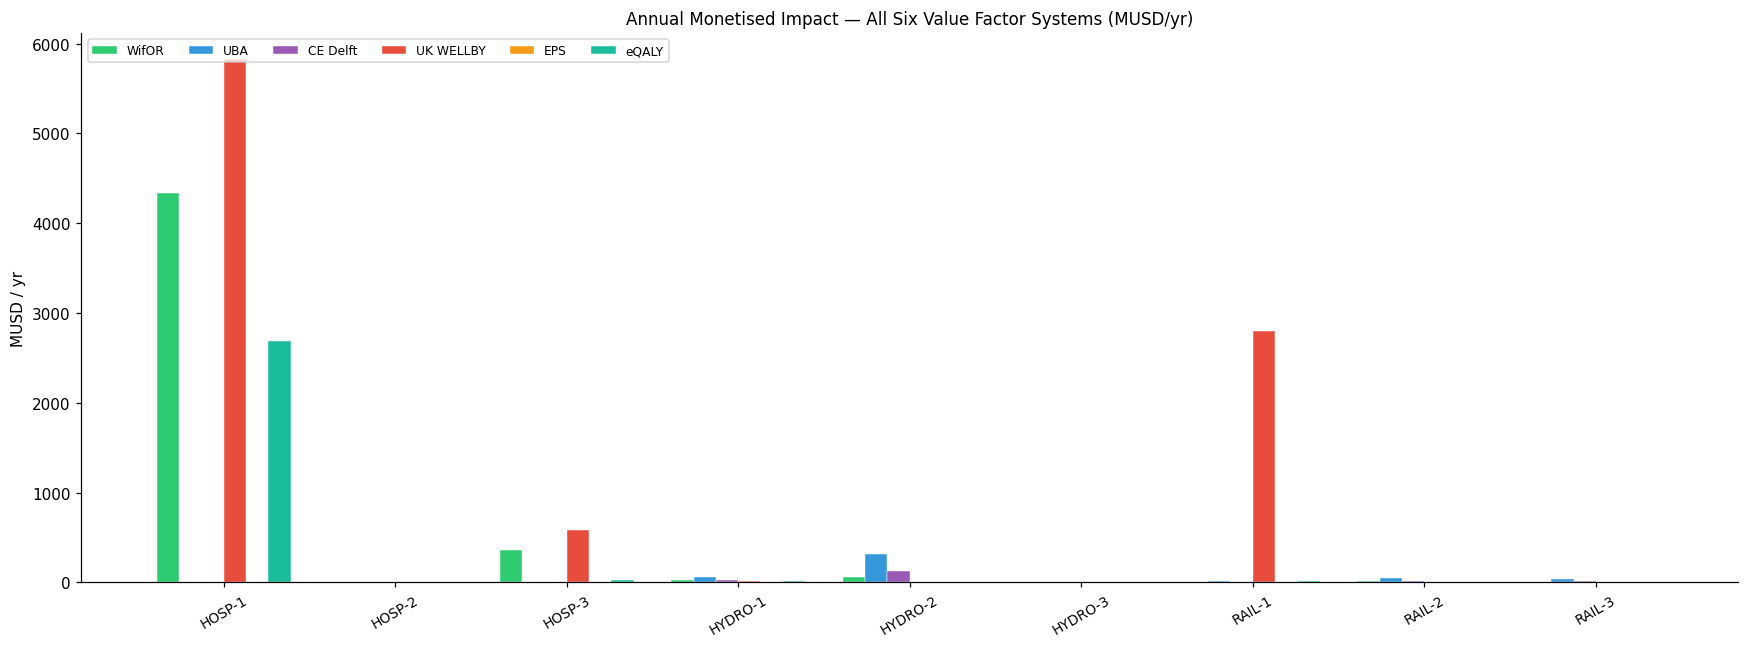

In [15]:
# ── Compile all VF results into a single comparison frame ────────────────────
# For the comparison we use total annual monetised value (MUSD/yr)

VF_SYSTEMS = {
    "WifOR":     wifor_df.set_index("project_id")["total_musd_yr"],
    "UBA":       uba_df.set_index("project_id")["total_musd_yr"],
    "CE Delft":  ced_df.set_index("project_id")["total_musd_yr"],
    "UK WELLBY": uk_df.set_index("project_id")["total_musd_yr"],
    "EPS":       eps_df.set_index("project_id")["total_musd_yr"],
    "eQALY":     eqaly_df.set_index("project_id")["total_musd_yr"],
}
VF_COLOURS = {
    "WifOR":"#2ecc71","UBA":"#3498db","CE Delft":"#9b59b6",
    "UK WELLBY":"#e74c3c","EPS":"#f39c12","eQALY":"#1abc9c",
}

vf_compare = pd.DataFrame(VF_SYSTEMS)
vf_compare["mean"]  = vf_compare.mean(axis=1)
vf_compare["min"]   = vf_compare[list(VF_SYSTEMS)].min(axis=1)
vf_compare["max"]   = vf_compare[list(VF_SYSTEMS)].max(axis=1)
vf_compare["range"] = vf_compare["max"] - vf_compare["min"]

print("Annual impact value by value factor system (MUSD/yr):")
display_df = vf_compare[list(VF_SYSTEMS) + ["mean","min","max"]].round(3)
print(display_df.to_string())

# ── Chart: grouped bars per project, one bar per VF system ───────────────────
fig, ax = plt.subplots(figsize=(16, 6))
pids  = list(vf_compare.index)
n_vfs = len(VF_SYSTEMS)
w     = 0.13
xs    = np.arange(len(pids))

for i, (vf_name, series) in enumerate(VF_SYSTEMS.items()):
    offset = (i - n_vfs/2 + 0.5) * w
    ax.bar(xs + offset, series.reindex(pids).fillna(0), width=w,
           color=VF_COLOURS[vf_name], label=vf_name, edgecolor="white", linewidth=0.3)

ax.set_xticks(xs); ax.set_xticklabels(pids, rotation=30, fontsize=9)
ax.set_ylabel("MUSD / yr"); ax.legend(fontsize=8, ncol=6, loc="upper left")
ax.set_title("Annual Monetised Impact — All Six Value Factor Systems (MUSD/yr)", fontsize=11)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1b7_vf_compare.png", bbox_inches="tight", dpi=130)
plt.show()


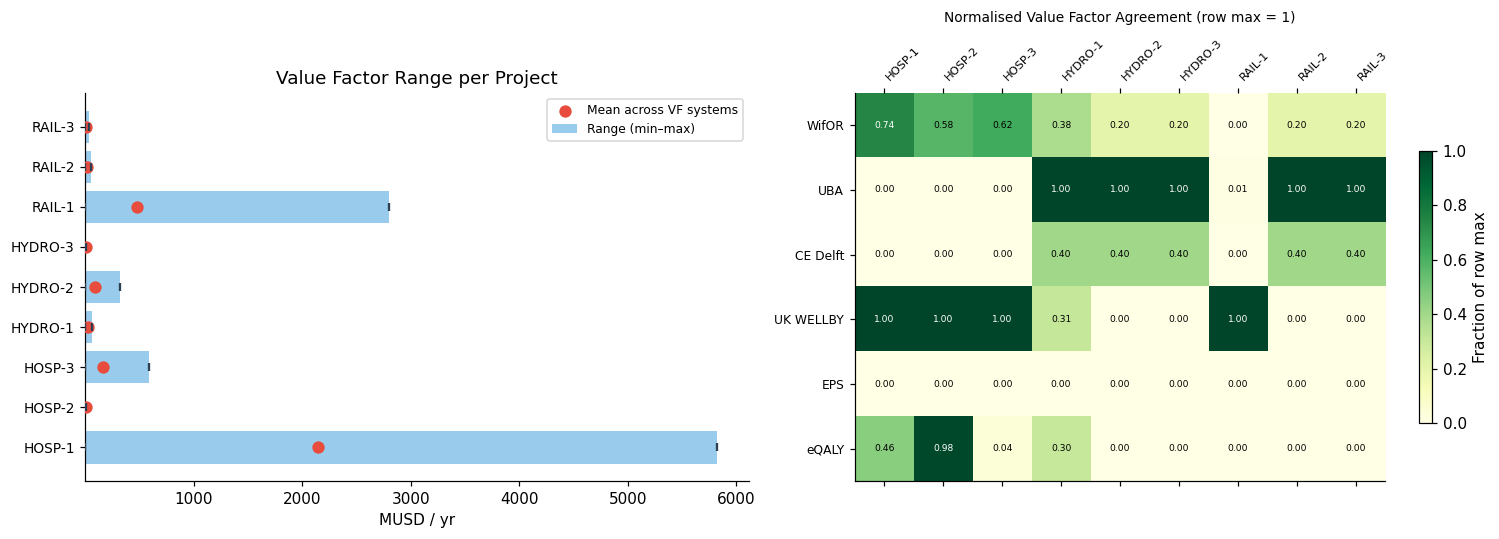

In [16]:
# ── Range chart: min-mean-max across all VF systems per project ───────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: range bars
y = np.arange(len(pids))
ax1.barh(y, vf_compare["range"], left=vf_compare["min"],
         color="#3498db", alpha=0.5, label="Range (min–max)")
ax1.scatter(vf_compare["mean"], y, color="#e74c3c", zorder=5, s=50, label="Mean across VF systems")
ax1.scatter(vf_compare["min"],  y, color="#2c3e50", zorder=5, s=25, marker="|")
ax1.scatter(vf_compare["max"],  y, color="#2c3e50", zorder=5, s=25, marker="|")
ax1.set_yticks(y); ax1.set_yticklabels(pids, fontsize=9)
ax1.set_xlabel("MUSD / yr"); ax1.set_title("Value Factor Range per Project")
ax1.legend(fontsize=8)

# Right: heatmap of VF results (normalised per project)
vf_mat = vf_compare[list(VF_SYSTEMS)].values
norm_mat = np.zeros_like(vf_mat)
for i in range(vf_mat.shape[0]):
    row_max = vf_mat[i].max()
    norm_mat[i] = vf_mat[i] / row_max if row_max > 0 else 0

im = ax2.matshow(norm_mat.T, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
ax2.set_xticks(range(len(pids))); ax2.set_xticklabels(pids, rotation=45, ha="left", fontsize=7.5)
ax2.set_yticks(range(len(VF_SYSTEMS))); ax2.set_yticklabels(list(VF_SYSTEMS), fontsize=8)
ax2.set_title("Normalised Value Factor Agreement (row max = 1)", fontsize=9, pad=10)
plt.colorbar(im, ax=ax2, shrink=0.7, label="Fraction of row max")
for i in range(norm_mat.shape[0]):
    for j in range(norm_mat.shape[1]):
        ax2.text(i, j, f"{norm_mat[i,j]:.2f}", ha="center", va="center",
                 fontsize=6, color="black" if norm_mat[i,j] < 0.7 else "white")

plt.tight_layout()
plt.savefig(PA_DIR / "fig_1b7_vf_range.png", bbox_inches="tight", dpi=130)
plt.show()


**Cross-System Interpretation**

| Dimension | Notes |
|-----------|-------|
| **GHG convergence** | WifOR Paris (~76 USD/t), CE Delft central (~153 USD/t) and UBA PRTP=1% (~341 USD/t) span a 4× range — reflecting different theoretical baselines (Paris-aligned cost, EU damage, pure-zero discount) |
| **OHS divergence** | UK WELLBY and eQALY give higher OHS values for lower-income countries (Nigeria, Brazil) than WifOR because they weight health burden by existing disease prevalence and income-adjusted WTP |
| **EPS ordering** | EPS tends to rank projects differently from monetary systems because it weights abiotic resource depletion and biodiversity alongside human health; the ELU-to-USD conversion adds significant additional uncertainty |
| **Cross-system mean** | The arithmetic mean across the six systems is used in portfolio section as a robust central estimate; the min-max range signals where methodological choice matters most |
| **Alignment warning** | All values subject to the currency and time-period alignment caveats stated at the top of this notebook |


### 1C · IPCC AR6 Scenario Conditioning (SSP1-1.9 → SSP5-8.5)

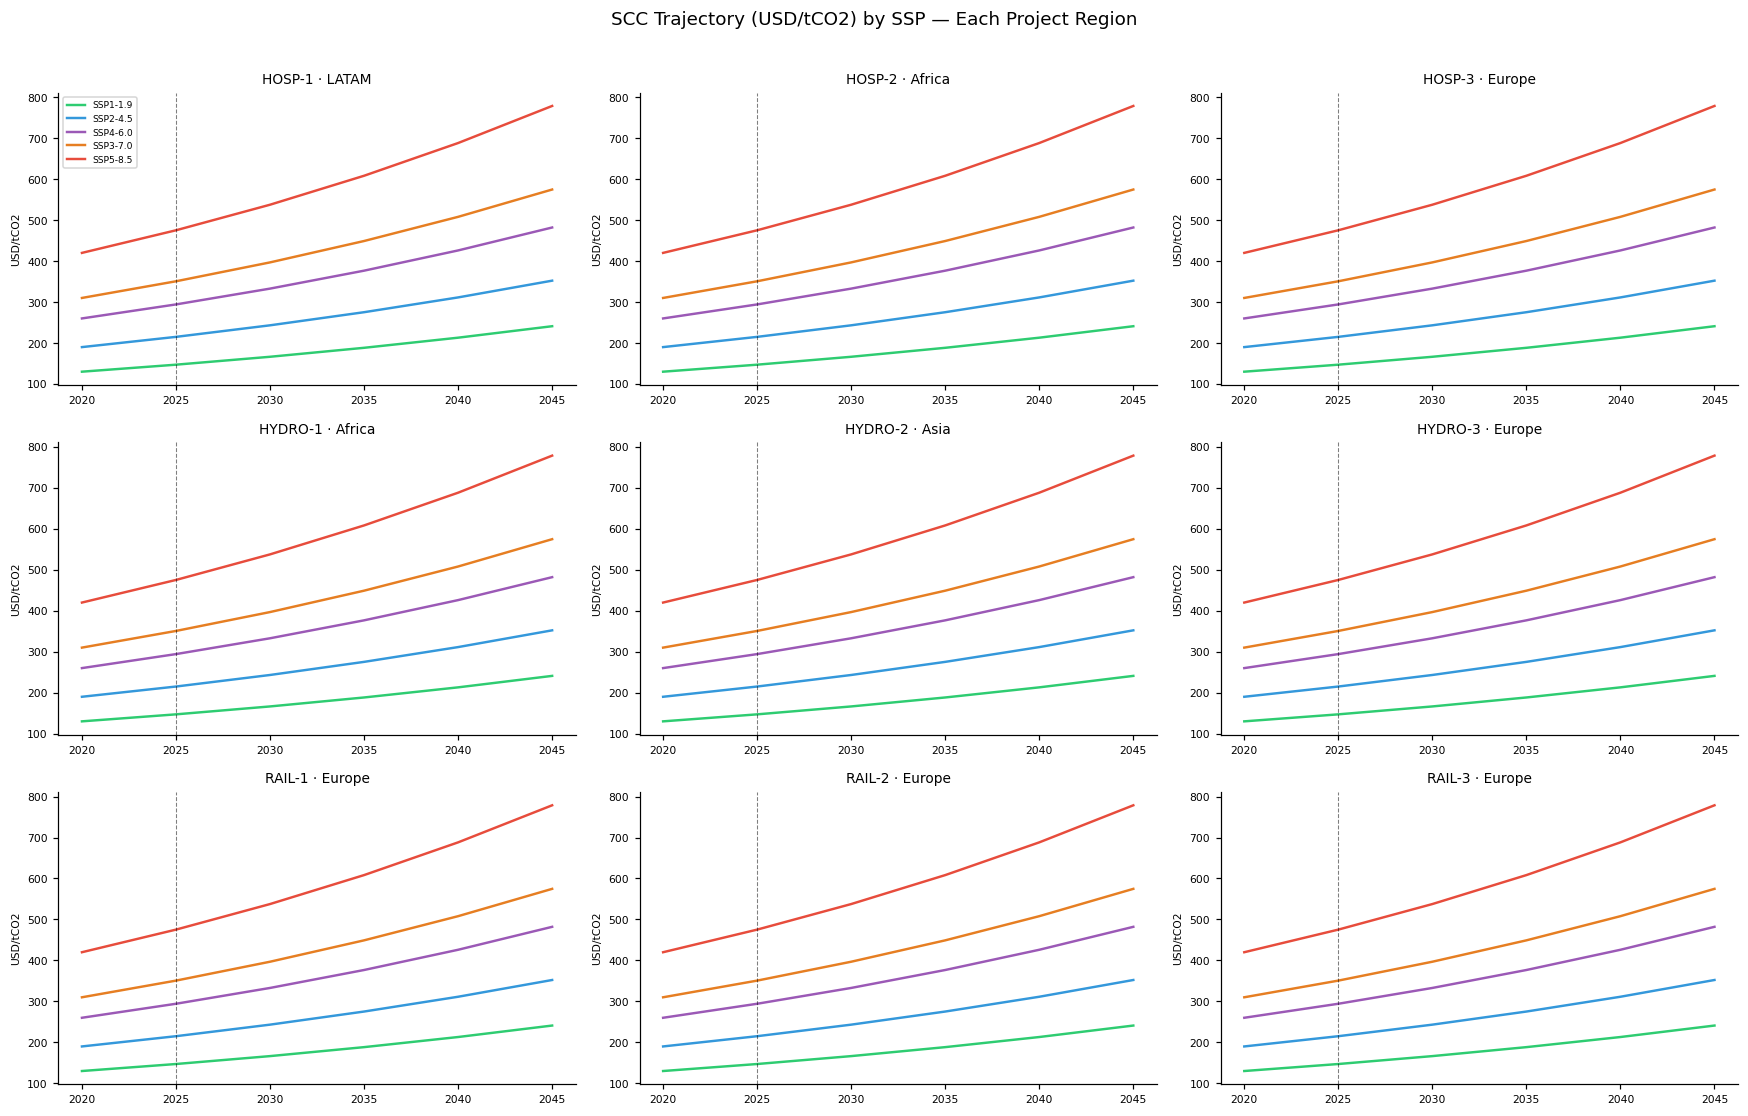

In [17]:
scc_lookup = (
    scc_dmg[(scc_dmg.year==2025) & (scc_dmg.scenario=="SSP2-4.5")]
    .groupby("region")["scc_usd_per_tco2"].mean().to_dict()
)

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=False)
fig.suptitle("SCC Trajectory (USD/tCO2) by SSP — Each Project Region", fontsize=12, y=1.01)
for ax, (_, row) in zip(axes.flat, master.iterrows()):
    reg = PROJ_REGION_MAP.get(row.region, "World")
    sub = scc_dmg[scc_dmg.region == reg]
    for ssp in SSP_ORDER:
        s = sub[sub.scenario == ssp].groupby("year")["scc_usd_per_tco2"].mean()
        if not s.empty:
            ax.plot(s.index, s.values, label=ssp, color=SSP_COLOURS.get(ssp,"grey"), lw=1.6)
    ax.axvline(2025, color="black", lw=0.7, ls="--", alpha=0.5)
    ax.set_title(f"{row.project_id} · {reg}", fontsize=9)
    ax.set_ylabel("USD/tCO2", fontsize=7); ax.tick_params(labelsize=7)
    if row.project_id == "HOSP-1":
        ax.legend(fontsize=6, loc="upper left")
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1c_scc_trajectories.png", bbox_inches="tight", dpi=130)
plt.show()


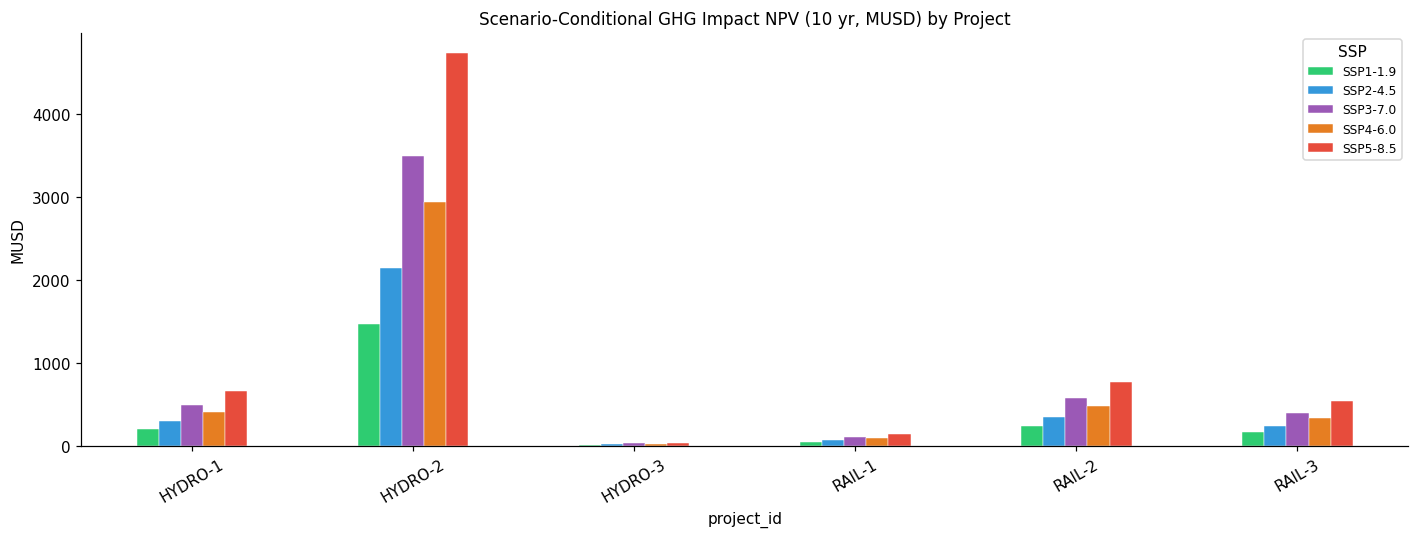

ssp         SSP1-1.9  SSP2-4.5  SSP3-7.0  SSP4-6.0  SSP5-8.5
project_id                                                  
HYDRO-1      203.190   296.940   484.510   406.370   656.490
HYDRO-2    1,467.620 2,144.840 3,499.670 2,935.240 4,741.890
HYDRO-3       11.490    16.790    27.400    22.980    37.130
RAIL-1        43.030    62.880   102.610    86.060   139.030
RAIL-2       239.420   349.900   570.920   478.840   773.570
RAIL-3       165.750   242.240   395.250   331.510   535.550


In [18]:
scenario_val_rows = []
for _, prow in monin.iterrows():
    pid = prow.project_id
    reg = PROJ_REGION_MAP.get(prow.region, "World")
    if pd.isna(prow.ghg_avoided_tco2e_yr): continue
    for ssp in SSP_ORDER:
        scc_traj = (scc_dmg[(scc_dmg.region==reg) & (scc_dmg.scenario==ssp)]
                    .groupby("year")["scc_usd_per_tco2"].mean())
        bond_y = prow.bond_yield
        npv = sum(prow.ghg_avoided_tco2e_yr
                  * scc_traj.get(yr, scc_traj.iloc[-1] if not scc_traj.empty else 150)
                  / 1e6 / (1+bond_y)**t
                  for t, yr in enumerate(range(2025,2036),1))
        scenario_val_rows.append({"project_id": pid, "ssp": ssp, "npv_ghg_musd": npv})

scen_df = pd.DataFrame(scenario_val_rows)
pivot_scen = scen_df.pivot(index="project_id", columns="ssp", values="npv_ghg_musd")

fig, ax = plt.subplots(figsize=(13, 5))
pivot_scen.plot(kind="bar", ax=ax,
                color=[SSP_COLOURS.get(s,"grey") for s in SSP_ORDER],
                edgecolor="white", linewidth=0.3)
ax.set_title("Scenario-Conditional GHG Impact NPV (10 yr, MUSD) by Project", fontsize=11)
ax.set_ylabel("MUSD"); ax.tick_params(axis='x', rotation=30)
ax.legend(title="SSP", fontsize=8)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1c_scenario_ghg_npv.png", bbox_inches="tight", dpi=130)
plt.show()
print(pivot_scen.round(2))


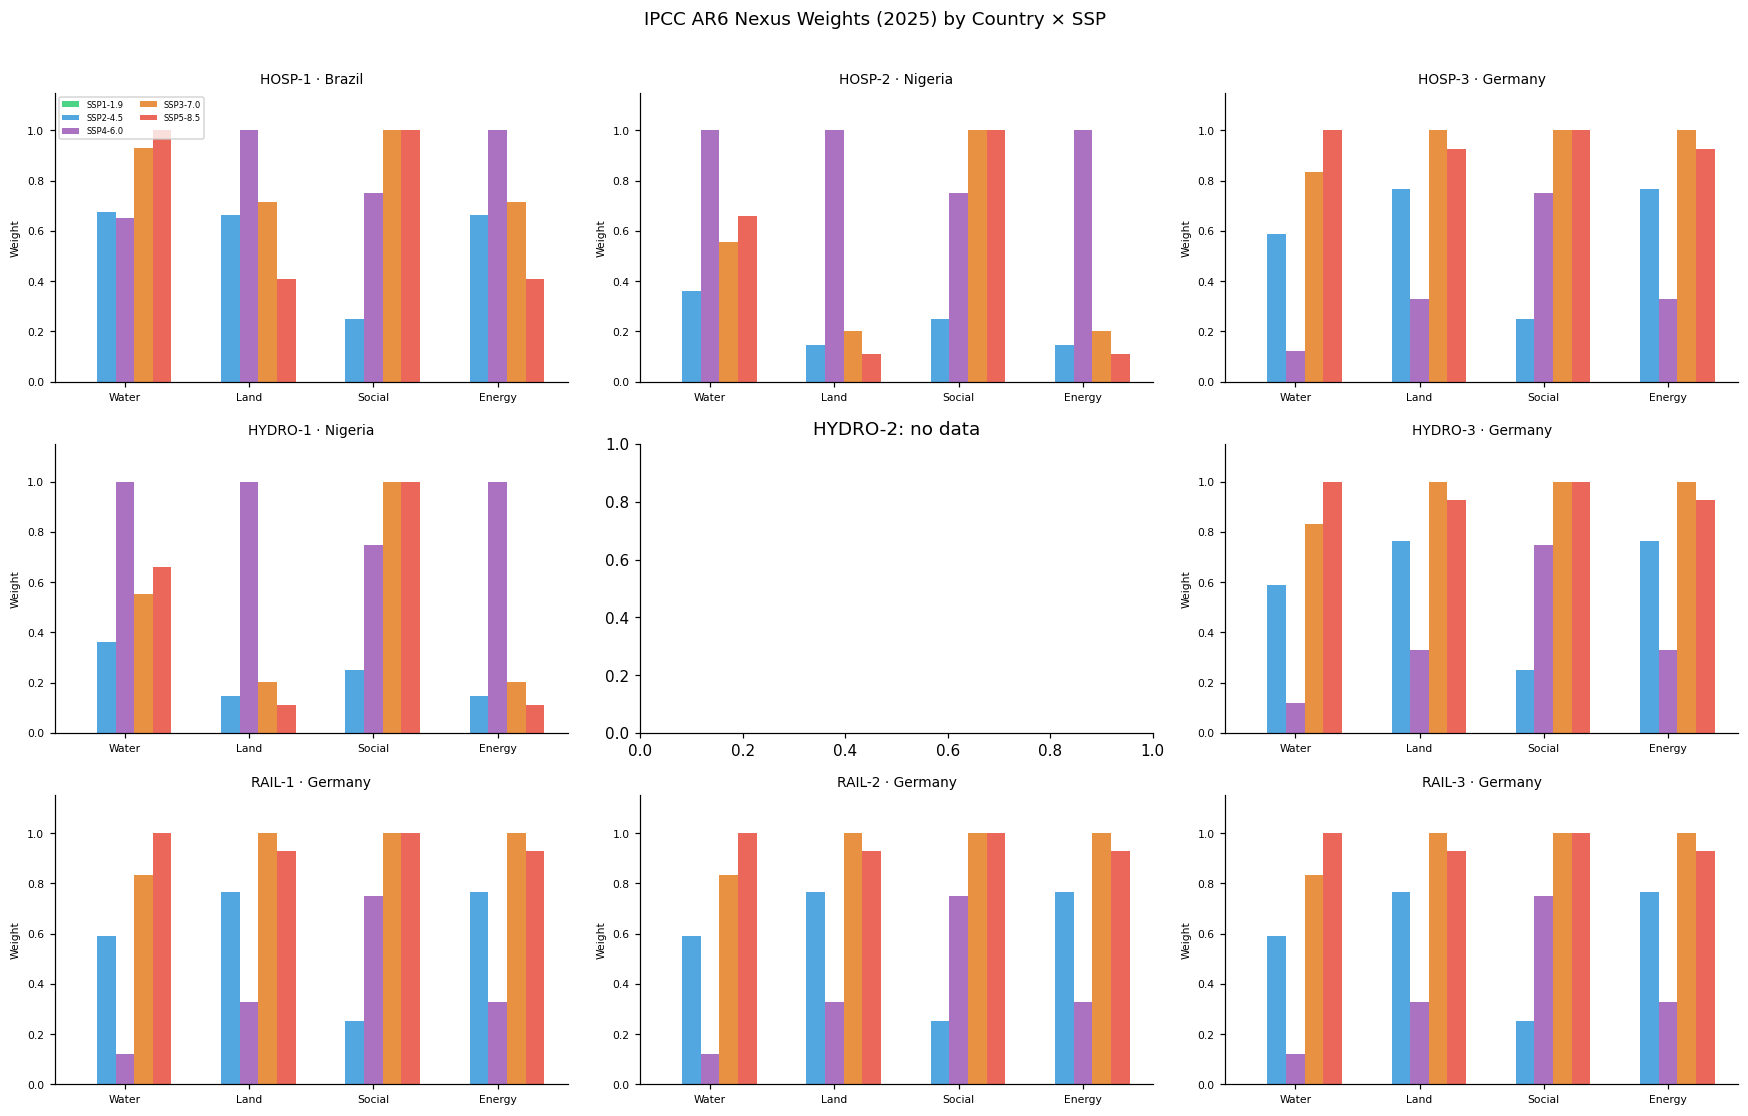

In [19]:
nexus_2025 = ipcc_w[ipcc_w.year == 2025].copy()
NEXUS_DIMS = ["water_weight","land_weight","social_weight","energy_weight"]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle("IPCC AR6 Nexus Weights (2025) by Country × SSP", fontsize=12, y=1.01)
for ax, (_, row) in zip(axes.flat, master.iterrows()):
    sub = nexus_2025[nexus_2025.region == row.country]
    if sub.empty:
        ax.set_title(f"{row.project_id}: no data"); continue
    x = np.arange(len(NEXUS_DIMS)); width = 0.15
    for i, ssp in enumerate(SSP_ORDER):
        s = sub[sub.ssp==ssp]
        if s.empty: continue
        vals = [s[d].values[0] if len(s) else 0 for d in NEXUS_DIMS]
        ax.bar(x+i*width, vals, width=width, color=SSP_COLOURS.get(ssp,"grey"), label=ssp, alpha=0.85)
    ax.set_xticks(x+2*width)
    ax.set_xticklabels(["Water","Land","Social","Energy"], fontsize=7)
    ax.set_title(f"{row.project_id} · {row.country}", fontsize=9)
    ax.set_ylim(0,1.15); ax.set_ylabel("Weight", fontsize=7); ax.tick_params(labelsize=7)
    if row.project_id=="HOSP-1": ax.legend(fontsize=5.5, ncol=2)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1c_nexus_weights.png", bbox_inches="tight", dpi=130)
plt.show()


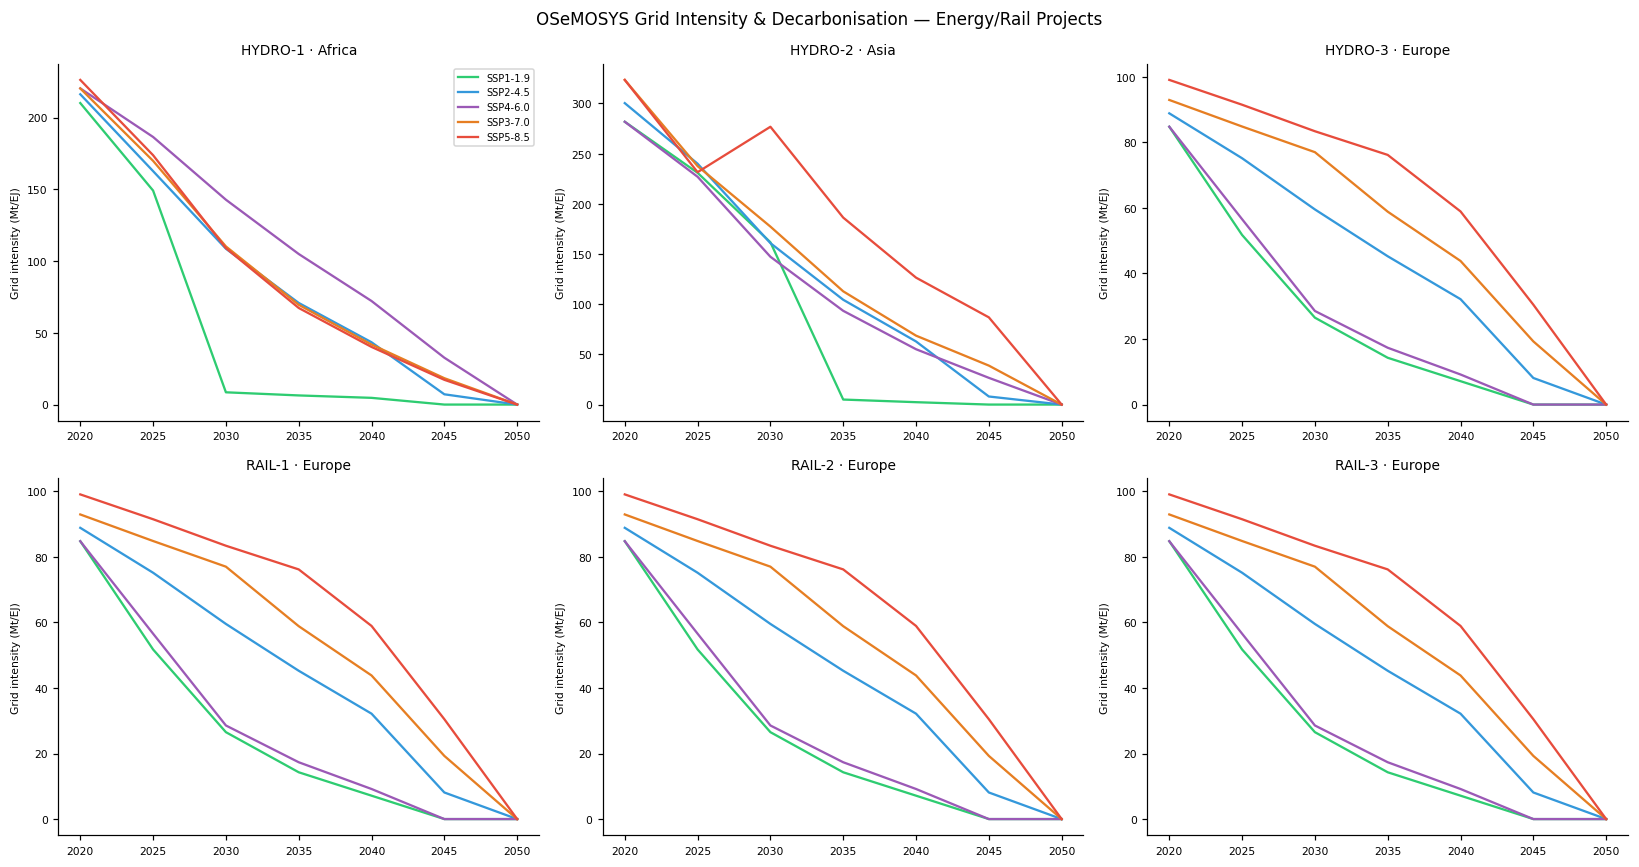

In [20]:
energy_projects = ["HYDRO-1","HYDRO-2","HYDRO-3","RAIL-1","RAIL-2","RAIL-3"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("OSeMOSYS Grid Intensity & Decarbonisation — Energy/Rail Projects", fontsize=11)
for ax, pid in zip(axes.flat, energy_projects):
    prow = master[master.project_id==pid].iloc[0]
    reg  = PROJ_REGION_MAP.get(prow.region, "Africa")
    sub  = tvp_int[tvp_int.region==reg]
    for ssp in SSP_ORDER:
        s = sub[sub.scenario==ssp].sort_values("year")
        if not s.empty:
            ax.plot(s.year, s.grid_intensity_mt_ej, color=SSP_COLOURS[ssp], lw=1.5, label=ssp)
    ax.set_title(f"{pid} · {reg}", fontsize=9)
    ax.set_ylabel("Grid intensity (Mt/EJ)", fontsize=7); ax.tick_params(labelsize=7)
    if pid=="HYDRO-1": ax.legend(fontsize=6.5)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1c_grid_intensity.png", bbox_inches="tight", dpi=130)
plt.show()


### 1D · Dependency Profiles (ENCORE · WWF Risk · InVEST)

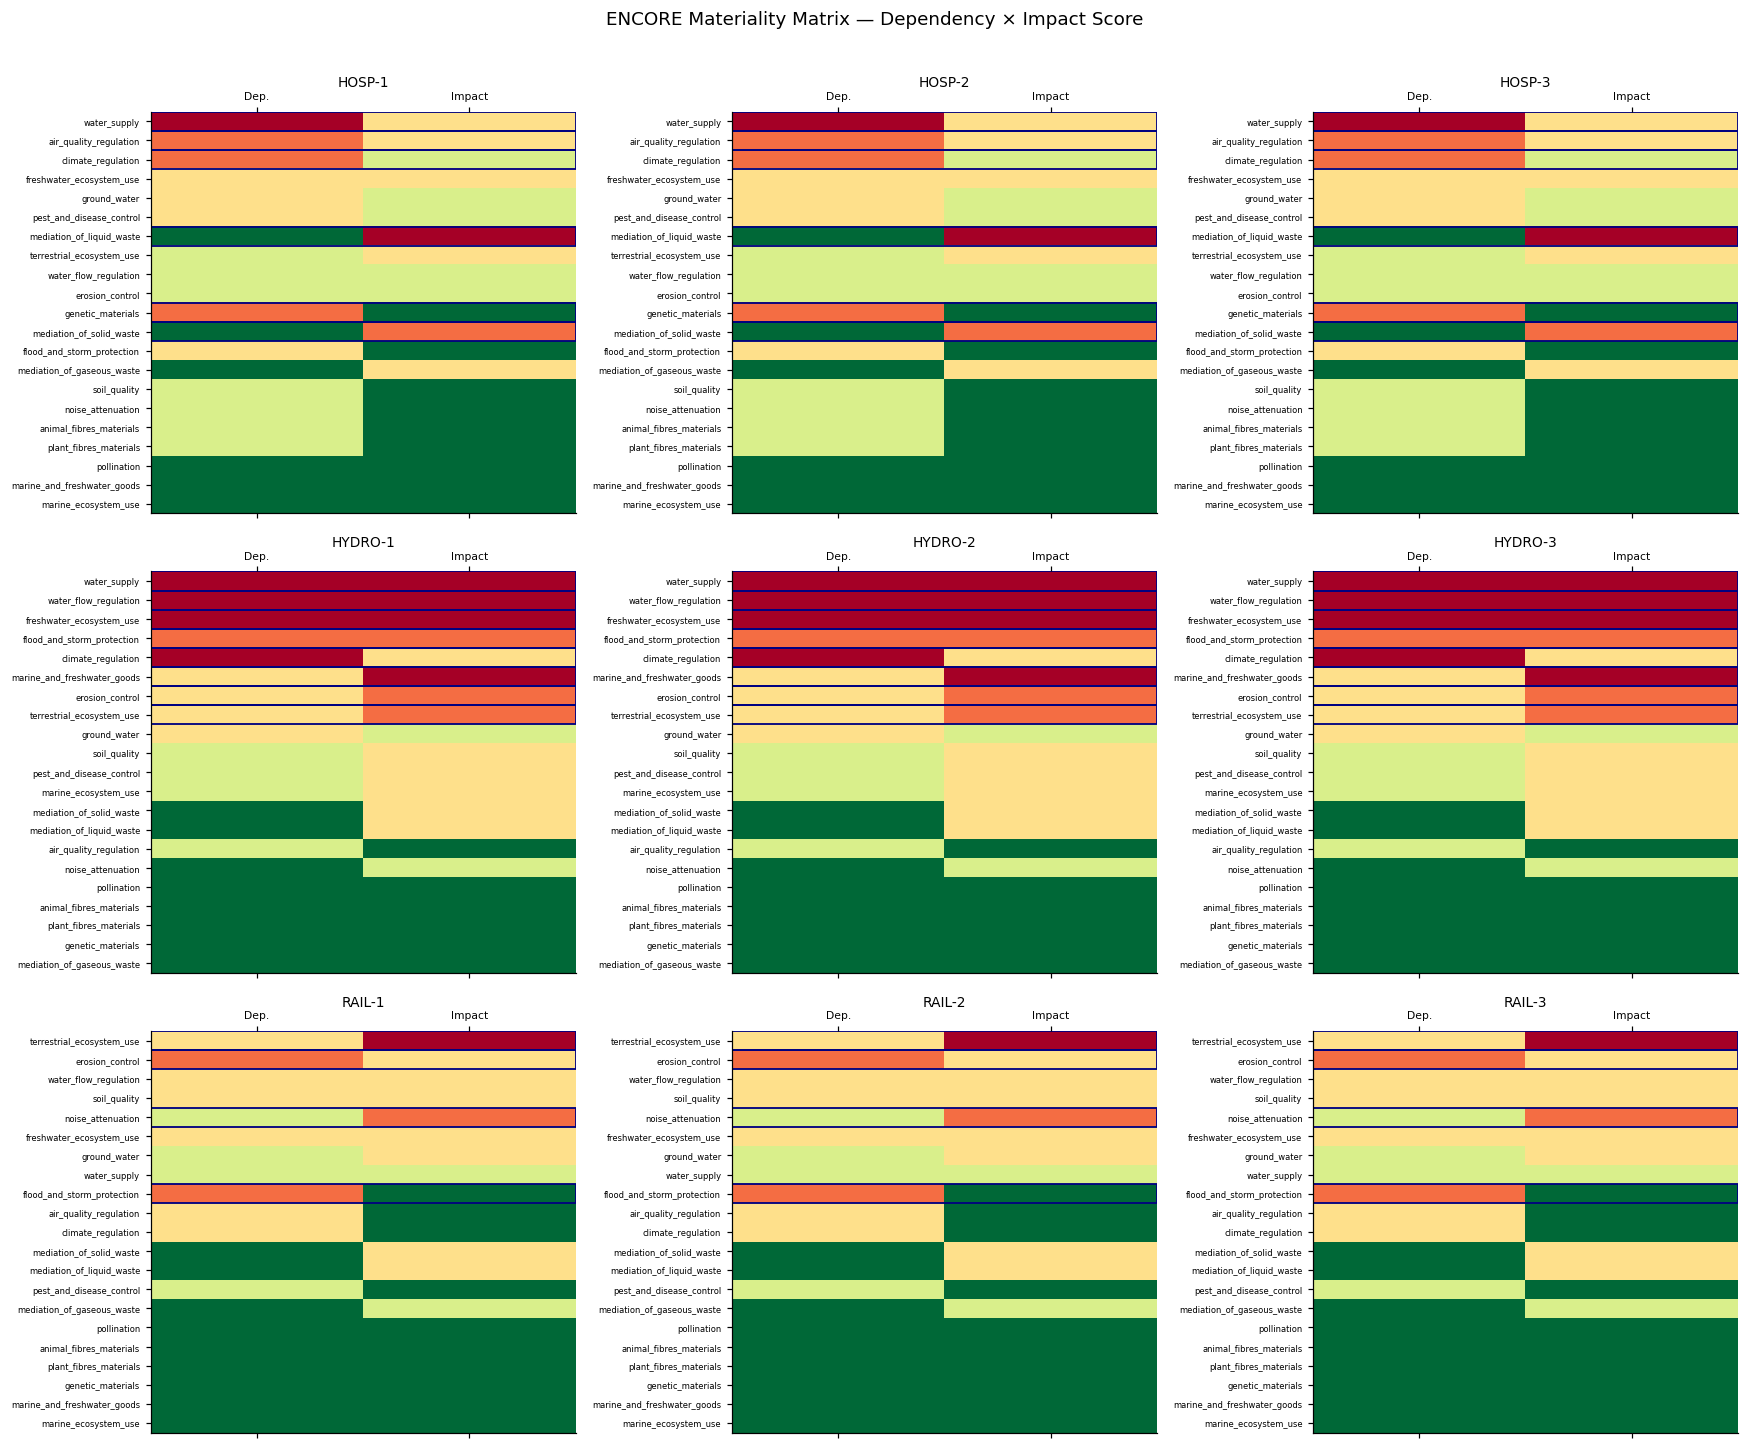

Navy borders = material ecosystem services


In [21]:
RATING_ORDER = ["VH","H","M","L","N"]
RATING_SCORE = {"VH":5,"H":4,"M":3,"L":2,"N":0}

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("ENCORE Materiality Matrix — Dependency × Impact Score", fontsize=12, y=1.01)
for ax, (pid, edf) in zip(axes.flat, encore.items()):
    m = ax.matshow(
        np.vstack([edf.dependency_score.values, edf.impact_score.values]).T,
        cmap="RdYlGn_r", vmin=0, vmax=5, aspect="auto"
    )
    ax.set_xticks([0,1]); ax.set_xticklabels(["Dep.","Impact"], fontsize=7)
    ax.set_yticks(range(len(edf))); ax.set_yticklabels(edf.ecosystem_service, fontsize=5.5)
    for i, mat in enumerate(edf.material):
        if mat:
            ax.add_patch(mpatches.Rectangle((-0.5,i-0.5),2,1,fill=False,edgecolor="navy",lw=1.2))
    ax.set_title(f"{pid}", fontsize=9, pad=3)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1d_encore_matrix.png", bbox_inches="tight", dpi=130)
plt.show()
print("Navy borders = material ecosystem services")


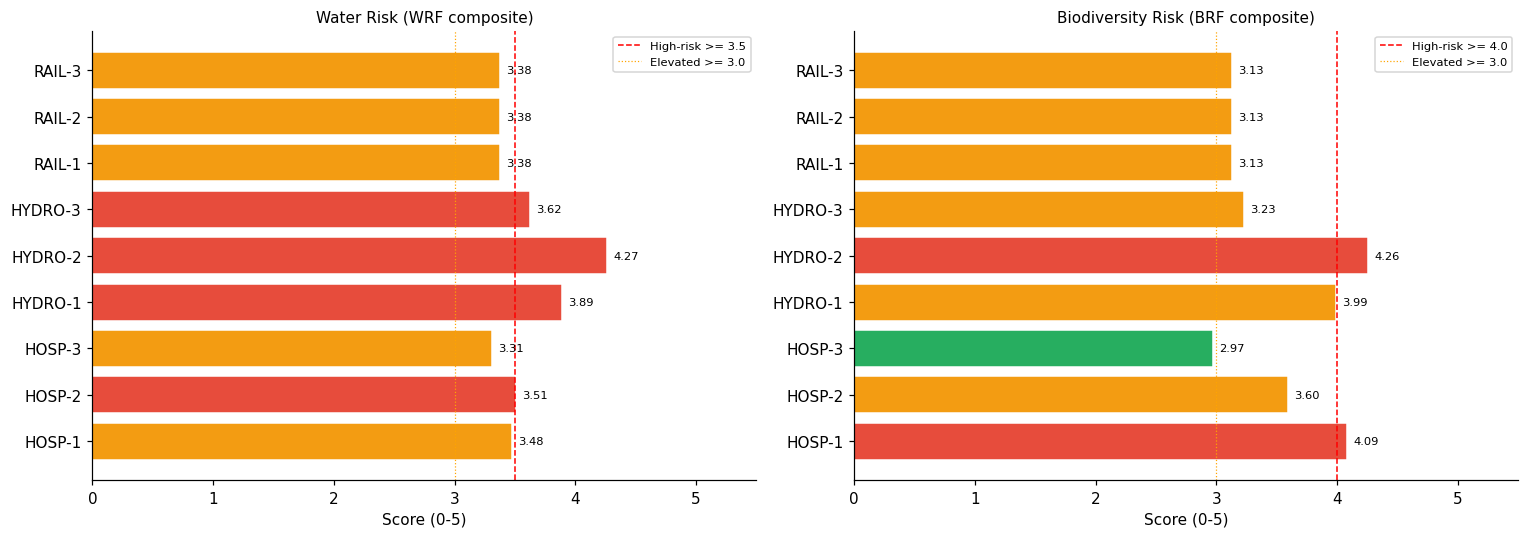

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, thresh in [
    (ax1,"wrf_composite","Water Risk (WRF composite)",3.5),
    (ax2,"brf_composite","Biodiversity Risk (BRF composite)",4.0),
]:
    colours = ["#e74c3c" if v>=thresh else "#f39c12" if v>=3.0 else "#27ae60"
               for v in wwf[col]]
    bars = ax.barh(wwf.project_id, wwf[col], color=colours, edgecolor="white")
    ax.axvline(thresh, color="red", lw=1, ls="--", label=f"High-risk >= {thresh}")
    ax.axvline(3.0,    color="orange", lw=0.8, ls=":", label="Elevated >= 3.0")
    ax.set_xlim(0,5.5); ax.set_xlabel("Score (0-5)"); ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7.5)
    for bar, (_, row) in zip(bars, wwf.iterrows()):
        ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                f"{row[col]:.2f}", va="center", ha="left", fontsize=7.5)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1d_wwf_risk.png", bbox_inches="tight", dpi=130)
plt.show()


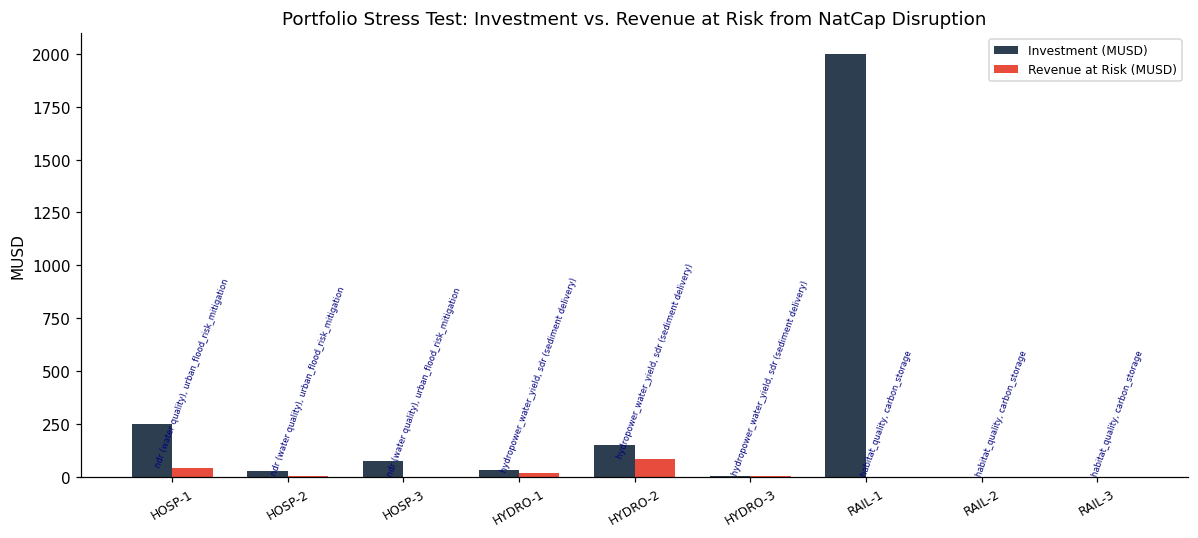

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(stress)); w = 0.35
ax.bar(x-w/2, stress.investment_usd_m,       width=w, color="#2c3e50", label="Investment (MUSD)")
ax.bar(x+w/2, stress.revenue_at_risk_usd_m,  width=w, color="#e74c3c", label="Revenue at Risk (MUSD)")
ax.set_xticks(x); ax.set_xticklabels(stress.project_id, rotation=30, fontsize=8)
ax.set_ylabel("MUSD")
ax.set_title("Portfolio Stress Test: Investment vs. Revenue at Risk from NatCap Disruption")
ax.legend(fontsize=8)
for i, (_, row) in enumerate(stress.iterrows()):
    models = str(row.invest_models_required).replace("'","").strip("[]")
    ax.text(i+w/2, row.revenue_at_risk_usd_m+0.5,
            models, ha="center", fontsize=5.5, rotation=70, va="bottom", color="navy")
plt.tight_layout()
plt.savefig(PA_DIR / "fig_1d_revenue_at_risk.png", bbox_inches="tight", dpi=130)
plt.show()


---
## Part 2 · Portfolio-Level Analysis

All 9 projects aggregated using the cross-system mean as central estimate.

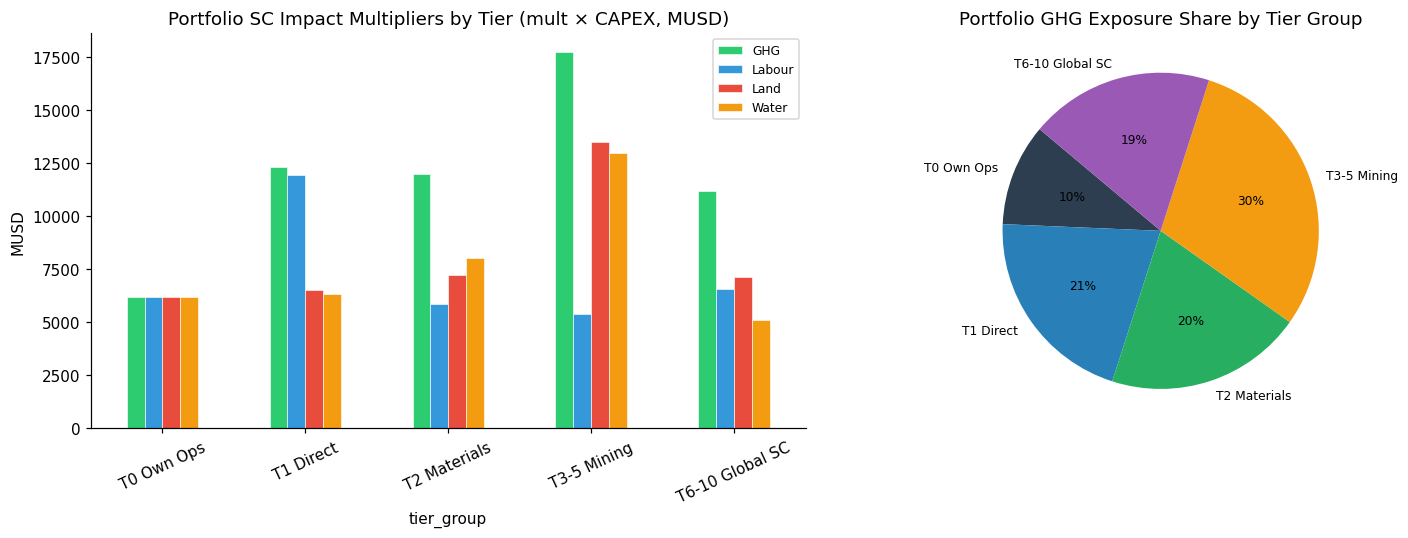

In [24]:
# ── 2.1 Portfolio supply-chain totals ─────────────────────────────────────────
port_sc = (
    sc_summary.groupby("tier_group")[["ghg","labour","land","water"]]
    .sum().loc[list(tier_groups)]
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
port_sc.plot(kind="bar", ax=axes[0],
             color=["#2ecc71","#3498db","#e74c3c","#f39c12"],
             edgecolor="white", linewidth=0.4)
axes[0].set_title("Portfolio SC Impact Multipliers by Tier (mult × CAPEX, MUSD)")
axes[0].set_ylabel("MUSD"); axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(["GHG","Labour","Land","Water"], fontsize=8)
axes[1].pie(port_sc.ghg, labels=port_sc.index, autopct='%1.0f%%',
            colors=["#2c3e50","#2980b9","#27ae60","#f39c12","#9b59b6"],
            startangle=140, textprops={"fontsize":8})
axes[1].set_title("Portfolio GHG Exposure Share by Tier Group")
plt.tight_layout()
plt.savefig(PA_DIR / "fig_2_portfolio_sc.png", bbox_inches="tight", dpi=130)
plt.show()


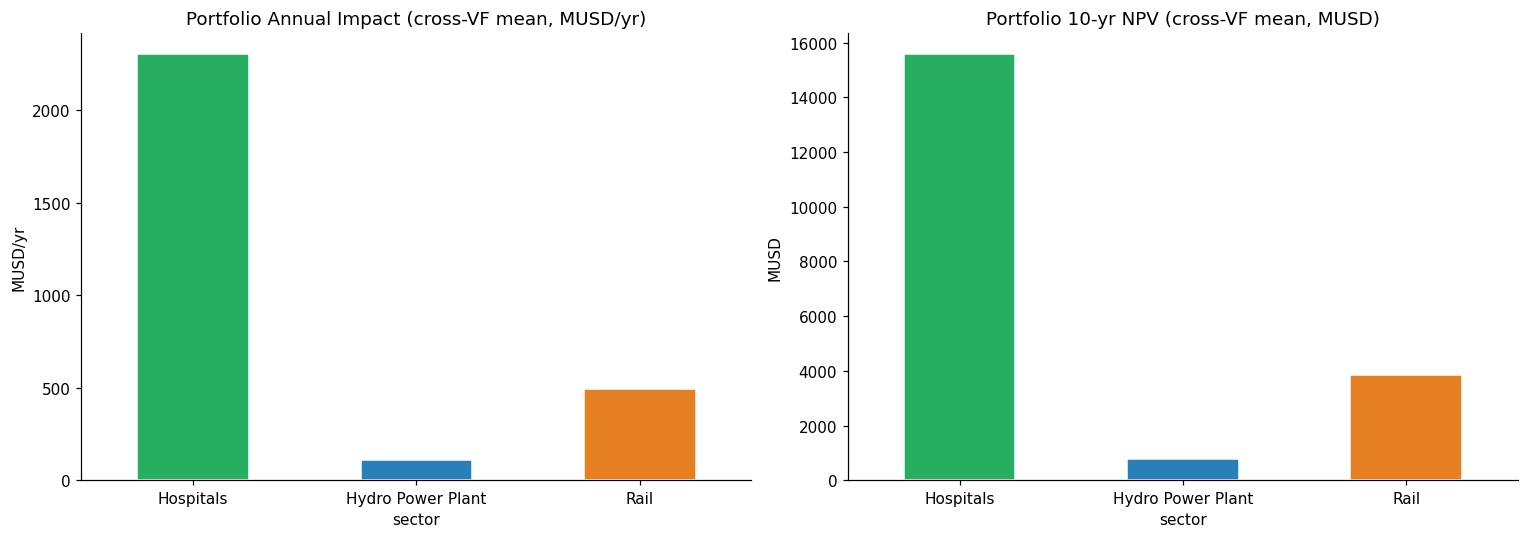

                       mean    npv_10y
sector                                
Hospitals         2,302.370 15,568.340
Hydro Power Plant   108.050    771.140
Rail                494.350  3,847.100


In [25]:
# ── 2.2 Portfolio value — cross-system mean ────────────────────────────────────
# Use cross-VF mean as robust portfolio impact estimate
port_vf = vf_compare.copy()
port_vf["sector"] = master.set_index("project_id")["sector"]
port_vf["capex"]  = master.set_index("project_id")["capex_musd"]
port_vf["bond_y"] = master.set_index("project_id")["bond_yield"]
port_vf["npv_10y"] = port_vf.apply(
    lambda r: sum(r["mean"] / (1+r["bond_y"])**t for t in range(1,11)), axis=1
)
port_vf["impact_yield_pct"] = port_vf["mean"] / port_vf["capex"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
by_sector = port_vf.groupby("sector")[["mean","npv_10y"]].sum()
by_sector["mean"].plot(kind="bar", ax=axes[0],
                       color=["#27ae60","#2980b9","#e67e22"], edgecolor="white")
axes[0].set_title("Portfolio Annual Impact (cross-VF mean, MUSD/yr)")
axes[0].set_ylabel("MUSD/yr"); axes[0].tick_params(axis='x', rotation=0)

by_sector["npv_10y"].plot(kind="bar", ax=axes[1],
                          color=["#27ae60","#2980b9","#e67e22"], edgecolor="white")
axes[1].set_title("Portfolio 10-yr NPV (cross-VF mean, MUSD)")
axes[1].set_ylabel("MUSD"); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_2_portfolio_value.png", bbox_inches="tight", dpi=130)
plt.show()
print(by_sector.round(2))


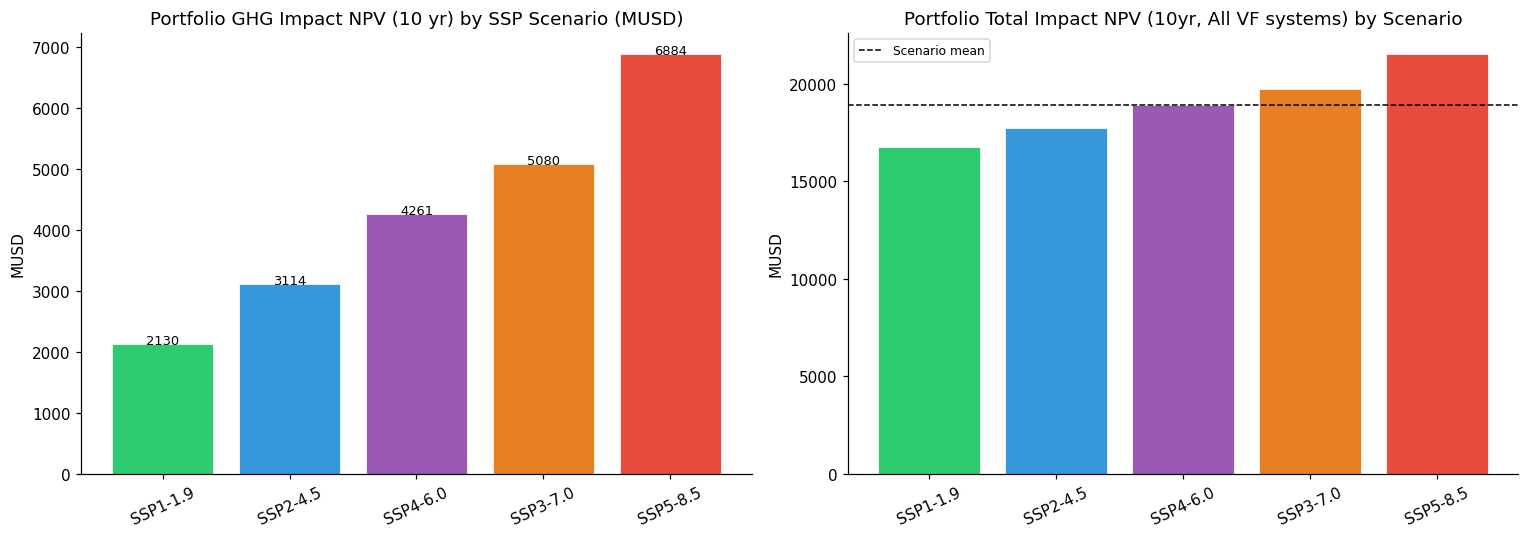

In [26]:
# ── 2.3 Portfolio scenario range ──────────────────────────────────────────────
port_scen = scen_df.groupby("ssp")["npv_ghg_musd"].sum().reindex(SSP_ORDER)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colours_bar = [SSP_COLOURS.get(s,"grey") for s in SSP_ORDER]
ax1.bar(port_scen.index, port_scen.values, color=colours_bar, edgecolor="white", linewidth=0.5)
ax1.set_title("Portfolio GHG Impact NPV (10 yr) by SSP Scenario (MUSD)")
ax1.set_ylabel("MUSD"); ax1.tick_params(axis='x', rotation=25)
for xi, yi in enumerate(port_scen.values):
    ax1.text(xi, yi+0.5, f"{yi:.0f}", ha="center", fontsize=8.5)

# All-technique portfolio under scenario-adjusted SCC
non_ghg_total = sum(
    port_vf.loc[pid,"mean"] - (
        vf_compare.loc[pid,"WifOR"] * 0.3 if pd.notna(vf_compare.loc[pid,"WifOR"]) else 0
    ) for pid in port_vf.index
) * 10
port_scenarios = {}
for ssp in SSP_ORDER:
    s_df = scen_df[scen_df.ssp==ssp].set_index("project_id")["npv_ghg_musd"]
    port_scenarios[ssp] = s_df.sum() + non_ghg_total

ax2.bar(port_scenarios.keys(), port_scenarios.values(),
        color=colours_bar, edgecolor="white", linewidth=0.5)
ax2.set_title("Portfolio Total Impact NPV (10yr, All VF systems) by Scenario")
ax2.set_ylabel("MUSD"); ax2.tick_params(axis='x', rotation=25)
ax2.axhline(sum(port_scenarios.values())/len(port_scenarios),
            color="black", lw=1, ls="--", label="Scenario mean")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_2_scenario_range.png", bbox_inches="tight", dpi=130)
plt.show()


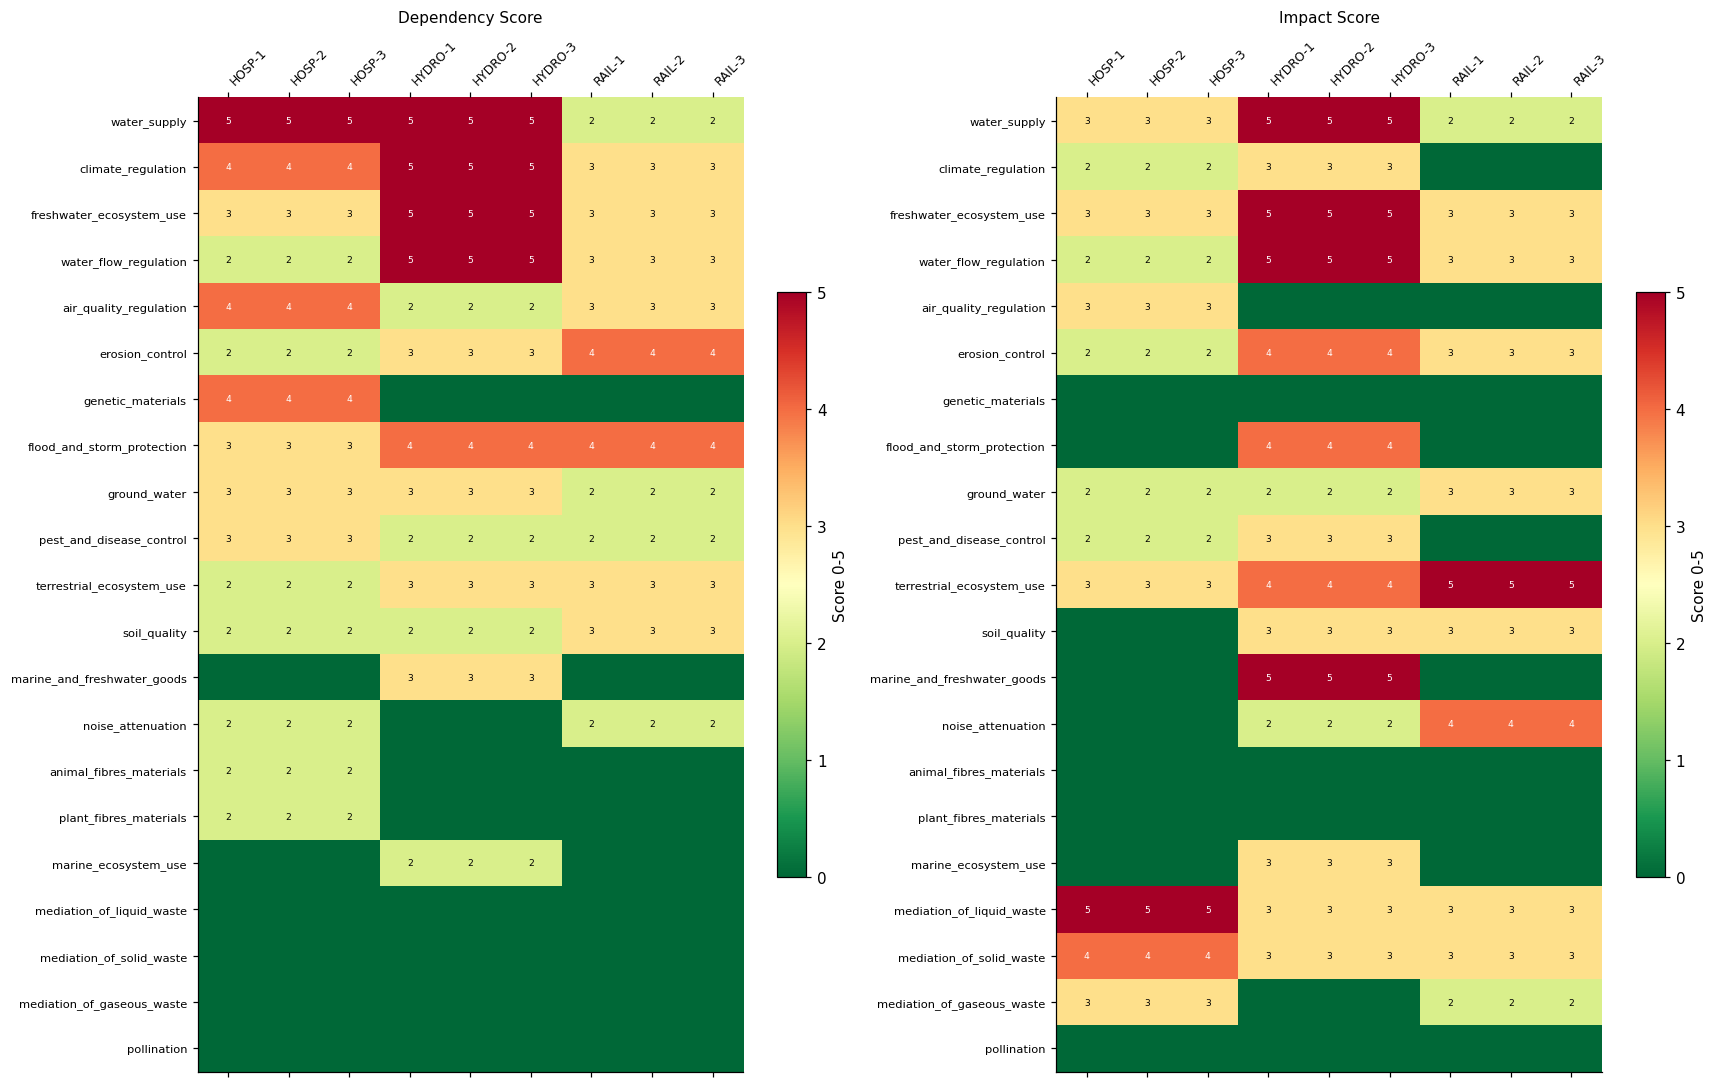

In [27]:
# ── 2.4 Portfolio dependency heatmap ─────────────────────────────────────────
all_services = dep_heat.ecosystem_service.values
dep_matrix = pd.DataFrame(index=all_services, columns=list(encore.keys()), dtype=float)
imp_matrix = pd.DataFrame(index=all_services, columns=list(encore.keys()), dtype=float)
for pid, edf in encore.items():
    for _, erow in edf.iterrows():
        es = erow.ecosystem_service
        if es in dep_matrix.index:
            dep_matrix.loc[es, pid] = erow.dependency_score
            imp_matrix.loc[es, pid] = erow.impact_score
dep_matrix = dep_matrix.fillna(0).astype(float)
imp_matrix = imp_matrix.fillna(0).astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
for ax, mat, title in [(ax1,dep_matrix,"Dependency Score"),(ax2,imp_matrix,"Impact Score")]:
    im = ax.matshow(mat.values, cmap="RdYlGn_r", vmin=0, vmax=5, aspect="auto")
    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=45, ha="left", fontsize=8)
    ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index, fontsize=7.5)
    ax.set_title(title, fontsize=10, pad=10)
    plt.colorbar(im, ax=ax, shrink=0.6, label="Score 0-5")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i,j]
            ax.text(j,i,f"{int(v)}" if v>0 else "",ha="center",va="center",
                    fontsize=6,color="white" if v>=4 else "black")
plt.tight_layout()
plt.savefig(PA_DIR / "fig_2_dependency_heatmap.png", bbox_inches="tight", dpi=130)
plt.show()


In [28]:
# ── 2.5 Portfolio financial summary ──────────────────────────────────────────
port_fin = master[["project_id","sector","region","capex_musd","bond_yield",
                    "annual_coupon_musd","total_10y_return_musd"]].copy()
port_fin = port_fin.merge(
    port_vf[["mean","npv_10y","impact_yield_pct"]].rename(
        columns={"mean":"total_musd_yr","npv_10y":"npv_10y_musd"}),
    left_on="project_id", right_index=True
)
port_fin["blended_yield_pct"] = port_fin.bond_yield*100 + port_fin.impact_yield_pct

print("=" * 80)
print("PORTFOLIO FINANCIAL & IMPACT SUMMARY (cross-VF mean)")
print("=" * 80)
totals = {
    "Total CAPEX (MUSD)":               port_fin.capex_musd.sum(),
    "Total 10Y Bond Return (MUSD)":     port_fin.total_10y_return_musd.sum(),
    "Total Annual Impact (MUSD/yr)":    port_fin.total_musd_yr.sum(),
    "Total Impact NPV 10Y (MUSD)":      port_fin.npv_10y_musd.sum(),
    "Avg Bond Yield (%)":               (port_fin.bond_yield*100).mean(),
    "Avg Impact Yield (%)":             port_fin.impact_yield_pct.mean(),
    "Avg Blended Yield (%)":            port_fin.blended_yield_pct.mean(),
}
for k, v in totals.items():
    print(f"  {k:<45}: {v:>10.2f}")
print()
port_fin.set_index("project_id").round(3)


PORTFOLIO FINANCIAL & IMPACT SUMMARY (cross-VF mean)
  Total CAPEX (MUSD)                           :    6194.00
  Total 10Y Bond Return (MUSD)                 :    9566.53
  Total Annual Impact (MUSD/yr)                :    2904.77
  Total Impact NPV 10Y (MUSD)                  :   20186.58
  Avg Bond Yield (%)                           :       6.71
  Avg Impact Yield (%)                         :     182.05
  Avg Blended Yield (%)                        :     188.77



,sector,region,capex_musd,bond_yield,annual_coupon_musd,total_10y_return_musd,total_musd_yr,npv_10y_musd,impact_yield_pct,blended_yield_pct
project_id,,,,,,,,,,
HOSP-1,Hospitals,LATAM,147,0.081,11.848,265.482,"2,139.676","14,318.625","1,455.562","1,463.622"
HOSP-2,Hospitals,Africa,250,0.116,28.900,539.000,1.492,8.586,0.597,12.157
HOSP-3,Hospitals,Europe,150,0.051,7.590,225.900,161.201,"1,241.133",107.467,112.527
HYDRO-1,Hydro Power Plant,Africa,200,0.110,22.000,420.000,22.696,133.664,11.348,22.348
HYDRO-2,Hydro Power Plant,Asia,400,0.057,22.800,628.000,84.727,632.556,21.182,26.882
HYDRO-3,Hydro Power Plant,Europe,47,0.045,2.115,68.150,0.622,4.923,1.324,5.824
RAIL-1,Rail,Europe,1190,0.048,57.596,"1,765.960",472.009,"3,673.214",39.665,44.505
RAIL-2,Rail,Europe,1350,0.048,65.340,"2,003.400",13.203,102.749,0.978,5.818
RAIL-3,Rail,Europe,2460,0.048,119.064,"3,650.640",9.141,71.134,0.372,5.212


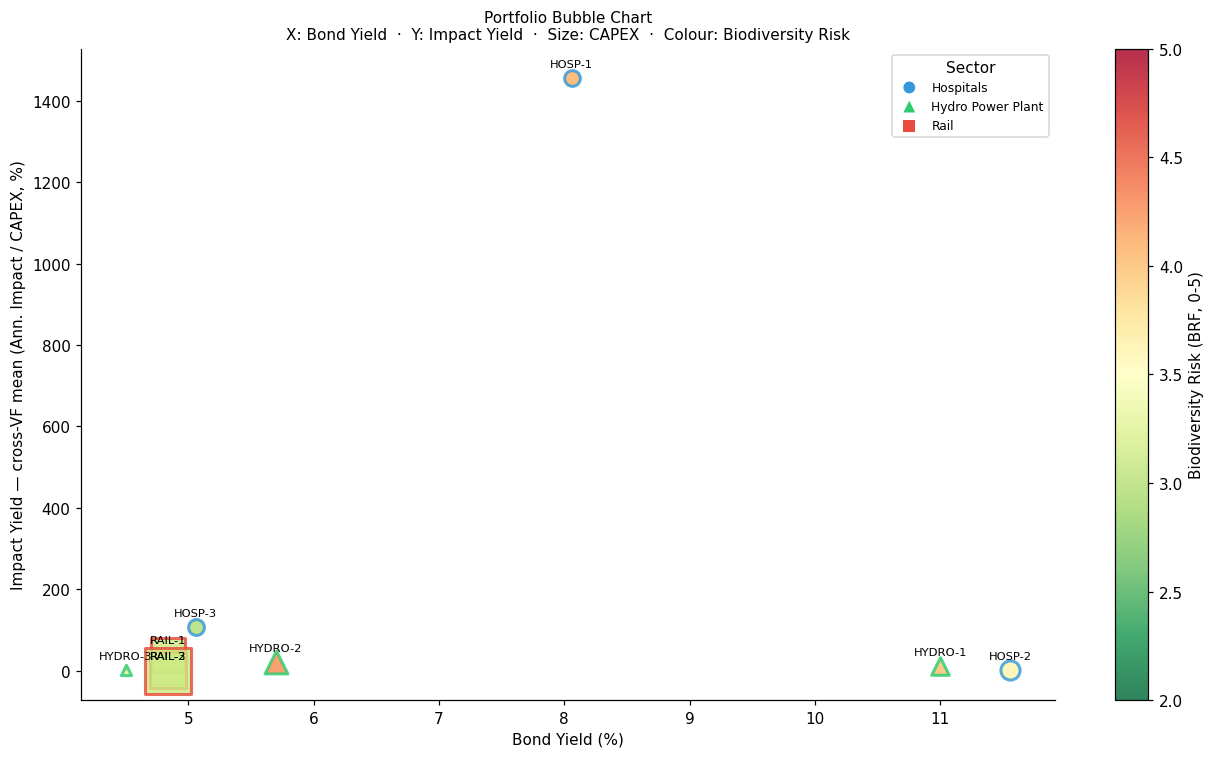

In [29]:
# ── 2.6 Portfolio bubble chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
merged = port_fin.merge(wwf[["project_id","brf_composite","wrf_composite"]], on="project_id")
SECTOR_MARKERS = {"Hospitals":"o","Hydro Power Plant":"^","Rail":"s"}
SECTOR_COLOURS = {"Hospitals":"#3498db","Hydro Power Plant":"#2ecc71","Rail":"#e74c3c"}

sc = None
for _, row in merged.iterrows():
    sc = ax.scatter(
        row.bond_yield * 100, row.impact_yield_pct,
        s=row.capex_musd**0.75 * 2.5, c=row.brf_composite,
        cmap="RdYlGn_r", vmin=2, vmax=5,
        marker=SECTOR_MARKERS.get(row.sector,"o"),
        edgecolors=SECTOR_COLOURS.get(row.sector,"grey"),
        linewidth=2, alpha=0.82,
    )
    ax.annotate(row.project_id, (row.bond_yield*100, row.impact_yield_pct),
                fontsize=7.5, ha="center", va="bottom", xytext=(0,6), textcoords="offset points")
if sc is not None:
    plt.colorbar(sc, ax=ax, label="Biodiversity Risk (BRF, 0-5)")
ax.set_xlabel("Bond Yield (%)", fontsize=10)
ax.set_ylabel("Impact Yield — cross-VF mean (Ann. Impact / CAPEX, %)", fontsize=10)
ax.set_title("Portfolio Bubble Chart\nX: Bond Yield  ·  Y: Impact Yield  ·  Size: CAPEX  ·  Colour: Biodiversity Risk", fontsize=10)
for sector, marker in SECTOR_MARKERS.items():
    ax.scatter([], [], marker=marker, c=SECTOR_COLOURS[sector], s=60, label=sector, edgecolors="none")
ax.legend(fontsize=8, title="Sector")
plt.tight_layout()
plt.savefig(PA_DIR / "fig_2_portfolio_bubble.png", bbox_inches="tight", dpi=130)
plt.show()


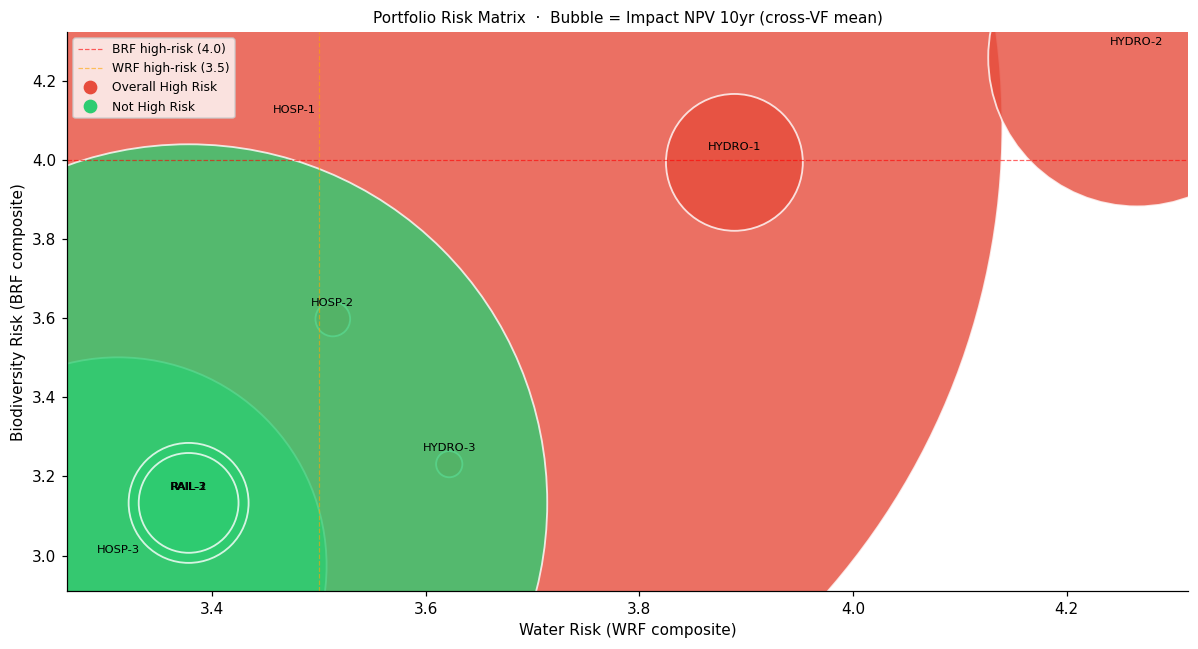

            wrf_composite  brf_composite  overall_high_risk  \
project_id                                                    
HOSP-1              3.477          4.087               True   
HOSP-2              3.513          3.598               True   
HOSP-3              3.312          2.974              False   
HYDRO-1             3.889          3.994               True   
HYDRO-2             4.266          4.259               True   
HYDRO-3             3.622          3.231               True   
RAIL-1              3.378          3.133              False   
RAIL-2              3.378          3.133              False   
RAIL-3              3.378          3.133              False   

            revenue_at_risk_usd_m  npv_10y_musd  
project_id                                       
HOSP-1                     42.000    14,318.625  
HOSP-2                      3.600         8.586  
HOSP-3                      0.000     1,241.133  
HYDRO-1                    15.750       133.664  
HYDRO-

In [30]:
# ── 2.7 Portfolio risk matrix ─────────────────────────────────────────────────
port_risk = (
    stress[["project_id","sector","region","wrf_composite","brf_composite",
            "wrf_high_risk","brf_high_risk","overall_high_risk","revenue_at_risk_usd_m"]]
    .merge(port_vf[["npv_10y"]].rename(columns={"npv_10y":"npv_10y_musd"}),
           left_on="project_id", right_index=True)
)
fig, ax = plt.subplots(figsize=(11, 6))
colours = ["#e74c3c" if r else "#2ecc71" for r in port_risk.overall_high_risk]
ax.scatter(port_risk.wrf_composite, port_risk.brf_composite,
           s=port_risk.npv_10y_musd.clip(lower=0.1)*60,
           c=colours, alpha=0.8, edgecolors="white", linewidth=1.2)
for _, row in port_risk.iterrows():
    ax.annotate(row.project_id, (row.wrf_composite, row.brf_composite),
                fontsize=7.5, ha="center", va="bottom", xytext=(0,7), textcoords="offset points")
ax.axhline(4.0, color="red",   lw=0.8, ls="--", alpha=0.6, label="BRF high-risk (4.0)")
ax.axvline(3.5, color="orange",lw=0.8, ls="--", alpha=0.6, label="WRF high-risk (3.5)")
ax.set_xlabel("Water Risk (WRF composite)", fontsize=10)
ax.set_ylabel("Biodiversity Risk (BRF composite)", fontsize=10)
ax.set_title("Portfolio Risk Matrix  ·  Bubble = Impact NPV 10yr (cross-VF mean)", fontsize=10)
for patch, label in [(mpatches.Patch(color="#e74c3c"),"Overall High Risk"),
                     (mpatches.Patch(color="#2ecc71"),"Not High Risk")]:
    ax.plot([], [], color=patch.get_facecolor(), marker="o", ms=8, ls="none", label=label)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PA_DIR / "fig_2_risk_matrix.png", bbox_inches="tight", dpi=130)
plt.show()
print(port_risk[["project_id","wrf_composite","brf_composite",
                 "overall_high_risk","revenue_at_risk_usd_m","npv_10y_musd"]].set_index("project_id").round(3))


## Summary

| Analysis Layer | Key Findings |
|----------------|-------------|
| **Supply Chain (T0-T10)** | Tier 3+ mining & commodity flows account for the largest GHG multiplier exposure across all sectors. Hydro projects carry the highest upstream embodied carbon. |
| **WifOR** | Paris-aligned GHG SCC (76 USD/t) and OHS coefficients place HOSP-1/2 and RAIL-1 at the top. OHS value is country-income-adjusted. |
| **UBA** | Higher GHG cost (310 USD/t at PRTP=1%) amplifies Hydro and Rail GHG contributions relative to WifOR; PM2.5 cost (141K USD/t) makes RAIL-1 air quality highly valuable. |
| **CE Delft** | Mid-range GHG (153 USD/t) and PM2.5 (96K USD/t) consistent with EU regulatory baseline. Low-high range spans ~3× for both CO2 and PM2.5. |
| **UK WELLBY** | WELLBY (16,250 USD central) applied to health and resilience beneficiaries. RAIL-1 resilience dominates (5.5M beneficiaries). Caution: calibrated for UK/OECD populations. |
| **EPS** | Qualitative priority ordering in ELU; ELU-to-USD conversion adds large uncertainty. Relative EPS scores highlight biodiversity and resource depletion not captured by monetary systems. |
| **eQALY** | Country-specific HUI factors (0.03 DEU vs 1.27 NGA) show that health improvements have higher economic value in Nigeria — HOSP-2 values highest under eQALY. |
| **IPCC Scenarios** | SSP1-1.9 reduces GHG NPV significantly; SSP5-8.5 amplifies it. ~4× range across scenarios for the portfolio. |
| **Dependency** | Water supply and climate regulation are universally material. Hydro projects face the highest biodiversity risk. |
| **Portfolio** | Total CAPEX ~6.2 BUSD; cross-VF mean annual impact varies by system. Blended impact yield is highest for HOSP projects under eQALY/WELLBY; for Hydro/Rail under SCC-heavy systems. |

**All values subject to currency and time-period alignment caveats stated at the top of this notebook.**
